# SomaTrack — Phase 2: Exploratory Data Analysis
**Project:** Predicting Study-Related Physical Ailments  
**Dataset:** 1,170 responses (270 original + 900 augmented) · 46 features · 7 targets  

---
## Table of Contents
1. [Setup & Data Loading](#1)  
2. [Univariate Analysis — Numeric Features](#2)  
3. [Univariate Analysis — Categorical & Ordinal Features](#3)  
4. [Target Variable Deep-Dive](#4)  
5. [Bivariate Analysis — Features vs Pain Targets](#5)  
6. [Correlation & Association Analysis](#6)  
7. [Engineered Features Analysis](#7)  
8. [Key Findings Summary](#8)  


## 1. Setup & Data Loading

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, kruskal
import warnings
warnings.filterwarnings('ignore')

# ── Palette & style ───────────────────────────────────────────────────────────
PAIN_COLORS  = ['#27ae60','#f39c12','#e67e22','#e74c3c']   # 0-None 1-Mild 2-Mod 3-Chronic
PAIN_LABELS  = ['None (0)','Mild (1)','Moderate (2)','Chronic (3)']
BLUE_PALETTE = ['#d6e8f5','#8bbcda','#4a90bf','#1a5a8a']
ACCENT       = '#2c6fad'

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

df = pd.read_csv('SomaTrack_ML_Ready.csv')

# Drop year_of_study as instructed
if 'year_of_study' in df.columns:
    df = df.drop(columns=['year_of_study'])

TARGET_COLS  = [c for c in df.columns if c.startswith('target_')]
FEATURE_COLS = [c for c in df.columns if not c.startswith('target_')]
NUMERIC_FEATS = ['sitting_hours','study_days_week','max_continuous_sit','screen_time','age']
ORDINAL_FEATS = ['break_frequency','break_duration','leave_desk','water_intake','caffeine_freq',
                 'stress_level','posture','lean_back','screen_eye_level','backpack_weight',
                 'lighting','exercise_freq','sleep_duration']

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Feature cols: {len(FEATURE_COLS)}  |  Target cols: {len(TARGET_COLS)}")
df.head(3)


Dataset: 1170 rows × 52 cols
Feature cols: 45  |  Target cols: 7


,sitting_hours,study_days_week,max_continuous_sit,break_frequency,break_duration,leave_desk,water_intake,caffeine_freq,screen_time,stress_level,...,input_method_external_keyboard_only,input_method_external_mouse_only,input_method_i_mainly_use_a_desktop_pc,input_method_laptop_trackpad_only,sit_break_ratio,ergonomic_risk,activity_balance,sleep_stress_index,hydration_index,digital_load
0,6.0,5,2.25,2,2,1,0,1,7.0,2,...,0,0,0,1,0.75,6,-1.5,9,0.000000,35.0
1,6.0,6,2.25,3,2,2,2,1,3.5,1,...,0,0,0,1,0.75,3,-1.5,6,0.285714,21.0
2,10.0,3,2.00,3,3,3,0,1,5.5,2,...,0,1,0,0,0.50,5,-1.5,9,0.000000,16.5


## 2. Univariate Analysis — Numeric Features

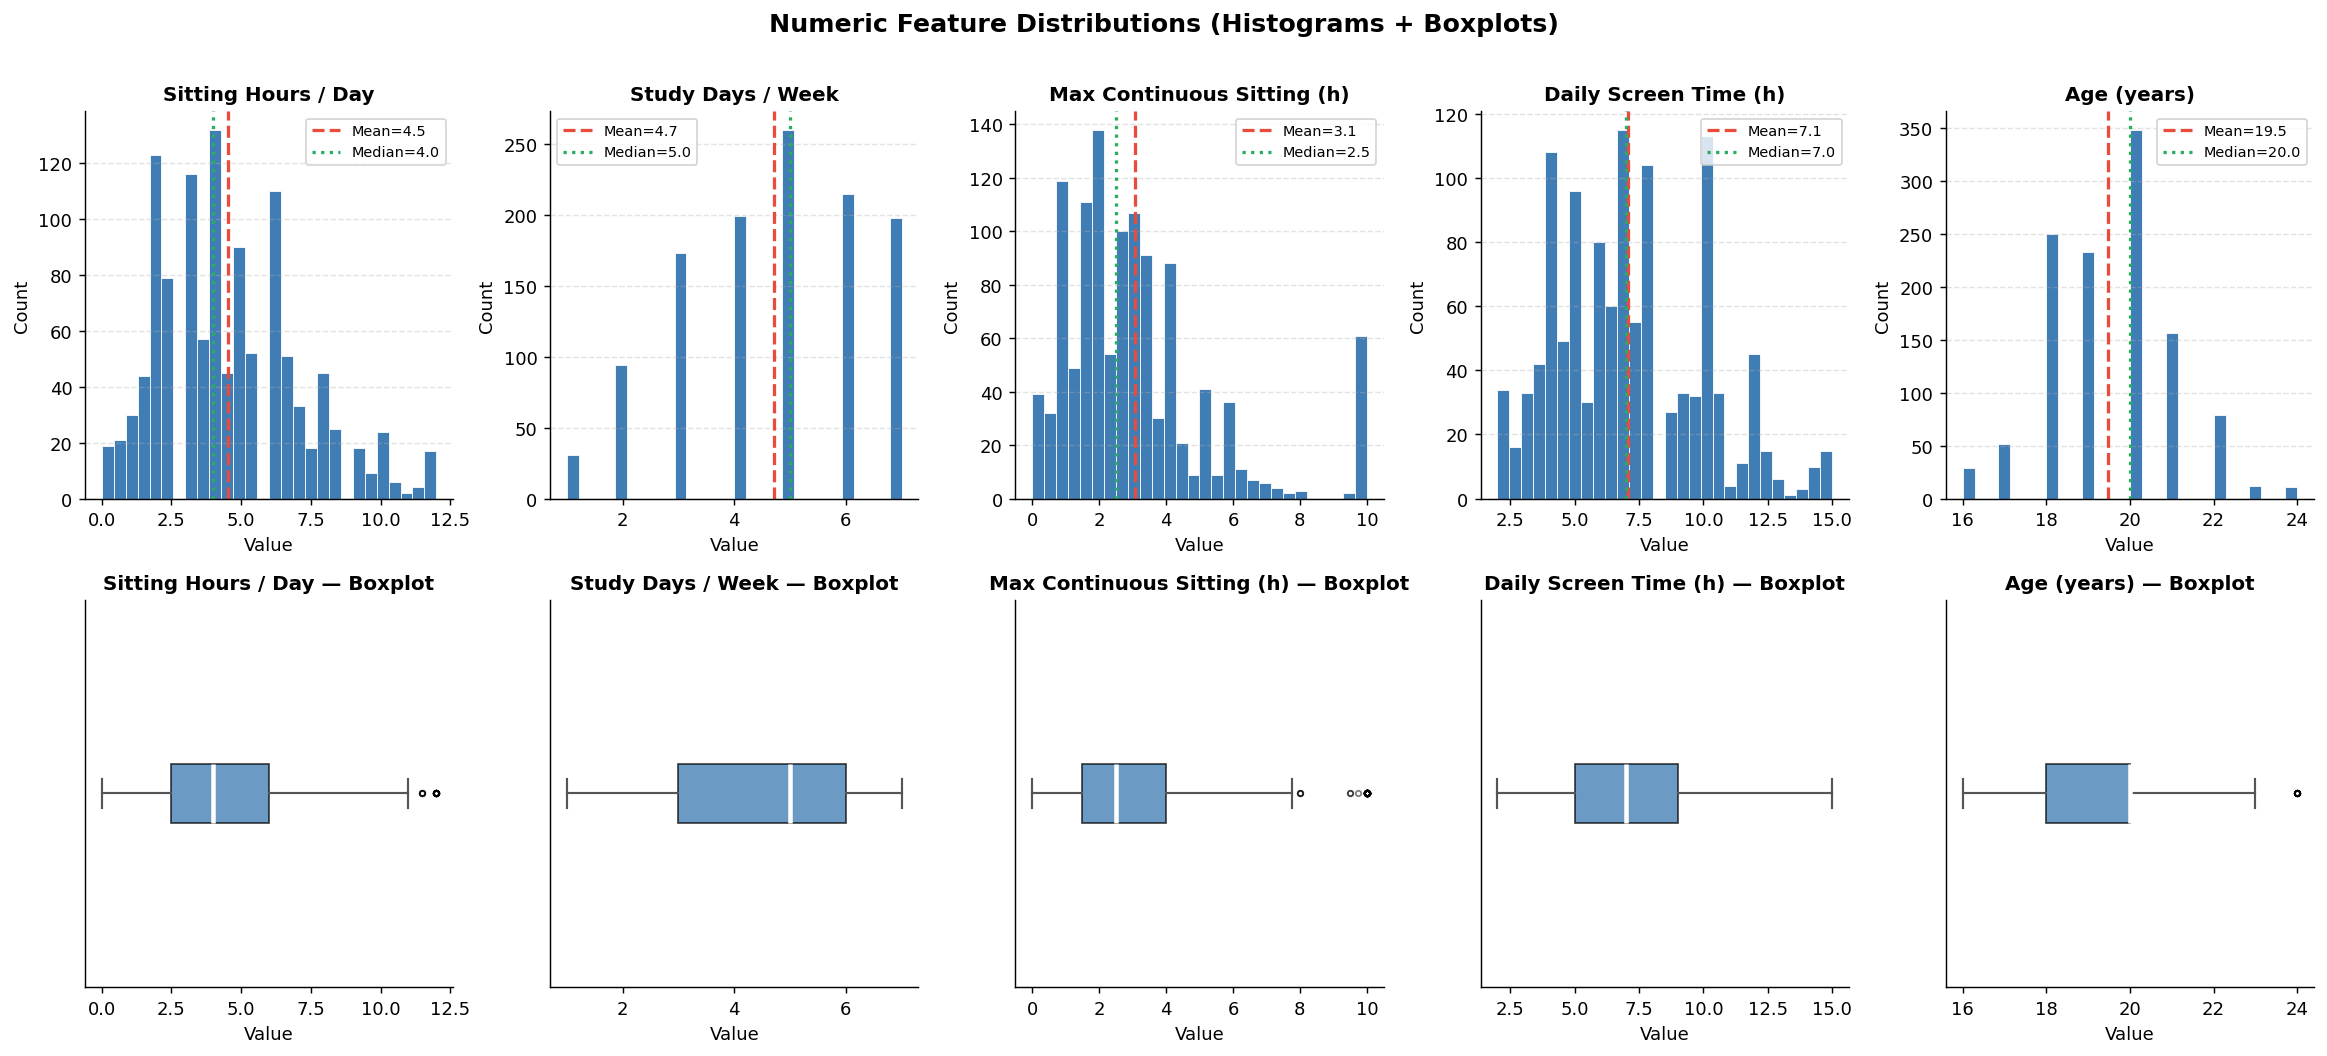

In [96]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

nice_names = {
    'sitting_hours':       'Sitting Hours / Day',
    'study_days_week':     'Study Days / Week',
    'max_continuous_sit':  'Max Continuous Sitting (h)',
    'screen_time':         'Daily Screen Time (h)',
    'age':                 'Age (years)',
}

for i, col in enumerate(NUMERIC_FEATS):
    # Histogram
    ax = axes[i]
    ax.hist(df[col], bins=28, color=ACCENT, edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.axvline(df[col].mean(),   color='#e74c3c', lw=1.8, linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='#27ae60', lw=1.8, linestyle=':',  label=f'Median={df[col].median():.1f}')
    ax.set_title(nice_names[col], fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    # Box-plot below
    ax2 = axes[i + 5]
    bp = ax2.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                     boxprops=dict(facecolor=ACCENT, alpha=0.7),
                     medianprops=dict(color='white', linewidth=2.5),
                     whiskerprops=dict(color='#555', lw=1.2),
                     capprops=dict(color='#555', lw=1.2),
                     flierprops=dict(marker='o', color='#e74c3c', markersize=3, alpha=0.5))
    ax2.set_xlabel('Value')
    ax2.set_yticks([])
    ax2.set_title(f'{nice_names[col]} — Boxplot', fontweight='bold')

plt.suptitle('Numeric Feature Distributions (Histograms + Boxplots)', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()


In [97]:
# Summary statistics table
stats_df = df[NUMERIC_FEATS].describe().round(2).T
stats_df.columns = ['N','Mean','Std','Min','Q1','Median','Q3','Max']
stats_df['Skew'] = df[NUMERIC_FEATS].skew().round(2)
print("=== Numeric Feature Statistics ===")
print(stats_df.to_string())


=== Numeric Feature Statistics ===
                         N   Mean   Std   Min    Q1  Median    Q3   Max  Skew
sitting_hours       1170.0   4.54  2.54   0.0   2.5     4.0   6.0  12.0  0.68
study_days_week     1170.0   4.71  1.64   1.0   3.0     5.0   6.0   7.0 -0.30
max_continuous_sit  1170.0   3.07  2.25   0.0   1.5     2.5   4.0  10.0  1.55
screen_time         1170.0   7.08  2.89   2.0   5.0     7.0   9.0  15.0  0.46
age                 1170.0  19.48  1.49  16.0  18.0    20.0  20.0  24.0  0.15


## 3. Univariate Analysis — Categorical & Ordinal Features

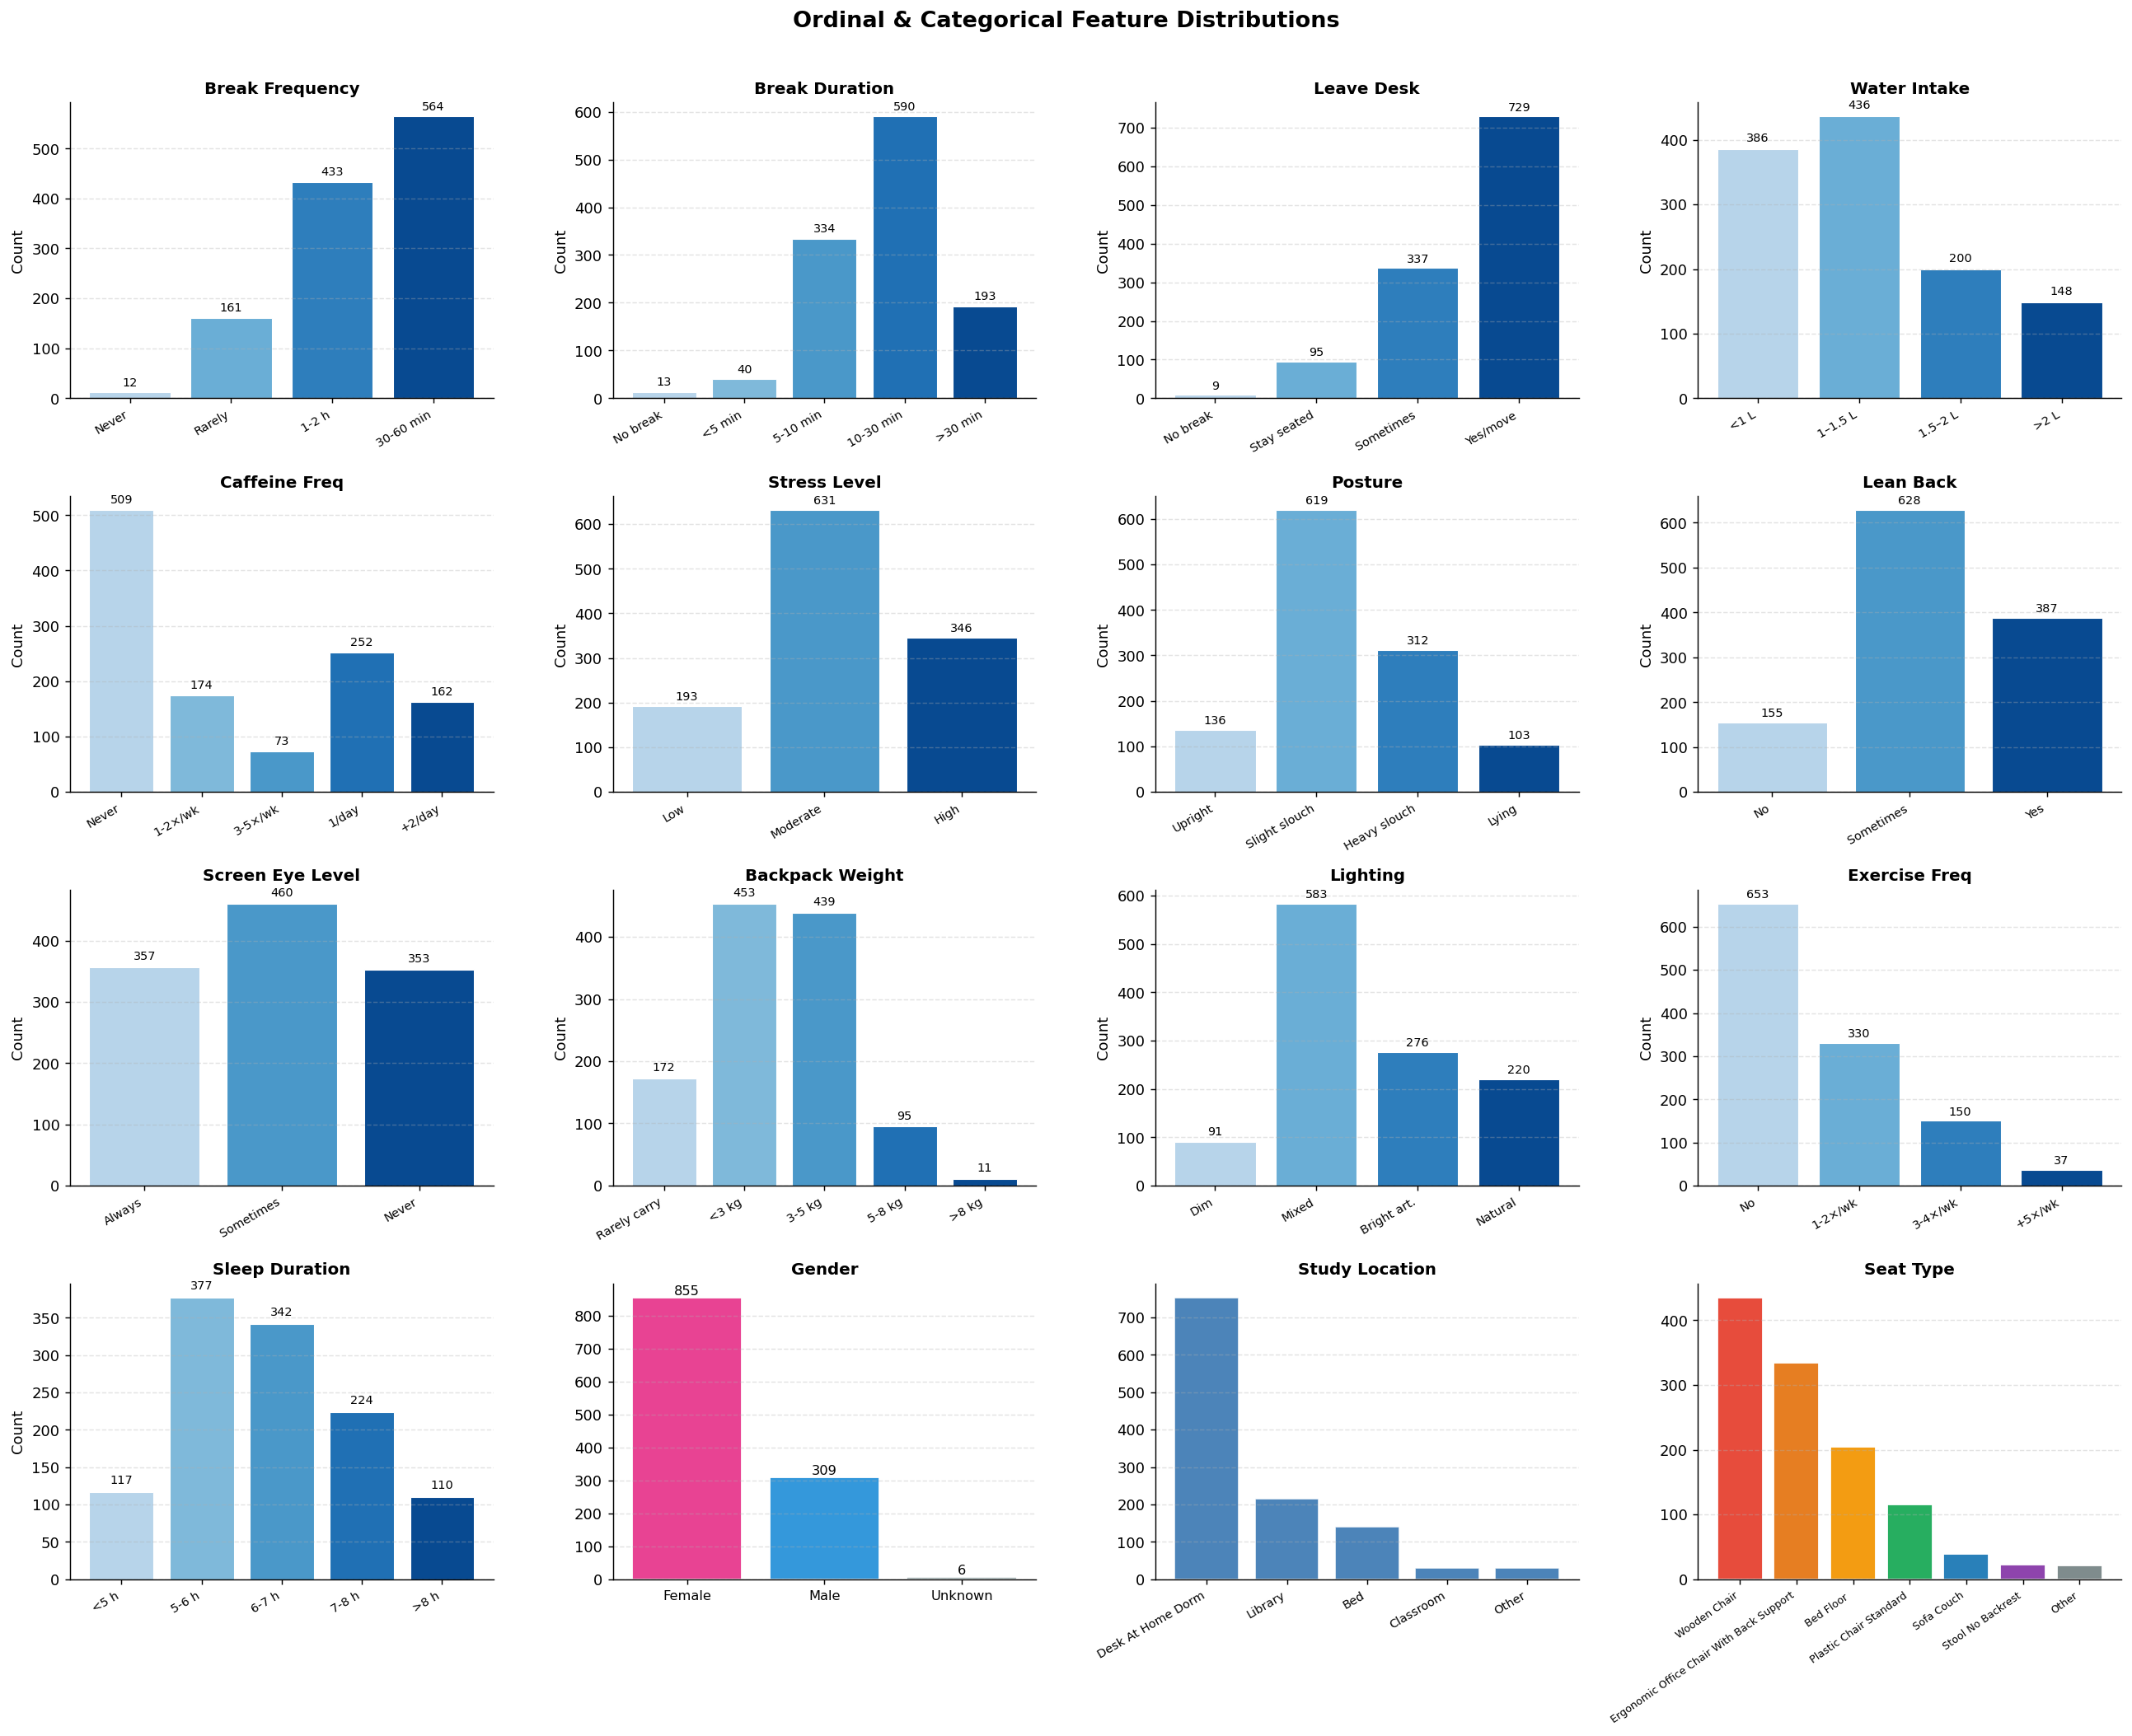

In [98]:
# Reverse-label maps for display
ordinal_labels = {
    'break_frequency':   {0:'Never',1:'Rarely',2:'1-2 h',3:'30-60 min'},
    'break_duration':    {0:'No break',1:'<5 min',2:'5-10 min',3:'10-30 min',4:'>30 min'},
    'leave_desk':        {0:'No break',1:'Stay seated',2:'Sometimes',3:'Yes/move'},
    'water_intake':      {0:'<1 L',1:'1–1.5 L',2:'1.5–2 L',3:'>2 L'},
    'caffeine_freq':     {0:'Never',1:'1-2×/wk',2:'3-5×/wk',3:'1/day',4:'+2/day'},
    'stress_level':      {0:'Low',1:'Moderate',2:'High'},
    'posture':           {0:'Upright',1:'Slight slouch',2:'Heavy slouch',3:'Lying'},
    'lean_back':         {0:'No',1:'Sometimes',2:'Yes'},
    'screen_eye_level':  {0:'Always',1:'Sometimes',2:'Never'},
    'backpack_weight':   {0:'Rarely carry',1:'<3 kg',2:'3-5 kg',3:'5-8 kg',4:'>8 kg'},
    'lighting':          {0:'Dim',1:'Mixed',2:'Bright art.',3:'Natural'},
    'exercise_freq':     {0:'No',1:'1-2×/wk',2:'3-4×/wk',3:'+5×/wk'},
    'sleep_duration':    {0:'<5 h',1:'5-6 h',2:'6-7 h',3:'7-8 h',4:'>8 h'},
}

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(ORDINAL_FEATS):
    ax = axes[i]
    vc = df[col].value_counts().sort_index()
    labels = [ordinal_labels[col].get(k, str(k)) for k in vc.index]
    cmap = plt.cm.Blues
    bar_colors = [cmap(0.3 + 0.6 * j / max(len(vc)-1, 1)) for j in range(len(vc))]
    bars = ax.bar(range(len(vc)), vc.values, color=bar_colors, edgecolor='white', linewidth=0.6)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(col.replace('_',' ').title(), fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                f'{v}', ha='center', va='bottom', fontsize=8)

# Gender bar
ax = axes[13]
vc = df['gender'].value_counts().sort_index()
gender_labels = {0:'Female',1:'Male',2:'Unknown'}
lbls = [gender_labels.get(k, str(k)) for k in vc.index]
ax.bar(range(len(vc)), vc.values, color=['#e84393','#3498db','#95a5a6'], edgecolor='white')
ax.set_xticks(range(len(vc)))
ax.set_xticklabels(lbls, fontsize=9)
ax.set_title('Gender', fontweight='bold')
for j, v in enumerate(vc.values):
    ax.text(j, v+8, str(v), ha='center', fontsize=9)

# Study location (OHE → reconstruct)
ax = axes[14]
loc_cols = [c for c in df.columns if c.startswith('study_location_')]
loc_counts = df[loc_cols].sum().sort_values(ascending=False)
loc_labels = [c.replace('study_location_','').replace('_',' ').title() for c in loc_counts.index]
ax.bar(range(len(loc_counts)), loc_counts.values, color=ACCENT, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(loc_counts)))
ax.set_xticklabels(loc_labels, rotation=30, ha='right', fontsize=8)
ax.set_title('Study Location', fontweight='bold')

# Seat type
ax = axes[15]
seat_cols = [c for c in df.columns if c.startswith('seat_type_')]
seat_counts = df[seat_cols].sum().sort_values(ascending=False)
seat_labels = [c.replace('seat_type_','').replace('_',' ').replace('no chair','').title() for c in seat_counts.index]
ax.bar(range(len(seat_counts)), seat_counts.values,
       color=['#e74c3c','#e67e22','#f39c12','#27ae60','#2980b9','#8e44ad','#7f8c8d'],
       edgecolor='white')
ax.set_xticks(range(len(seat_counts)))
ax.set_xticklabels(seat_labels, rotation=35, ha='right', fontsize=7)
ax.set_title('Seat Type', fontweight='bold')

plt.suptitle('Ordinal & Categorical Feature Distributions', fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Target Variable Deep-Dive

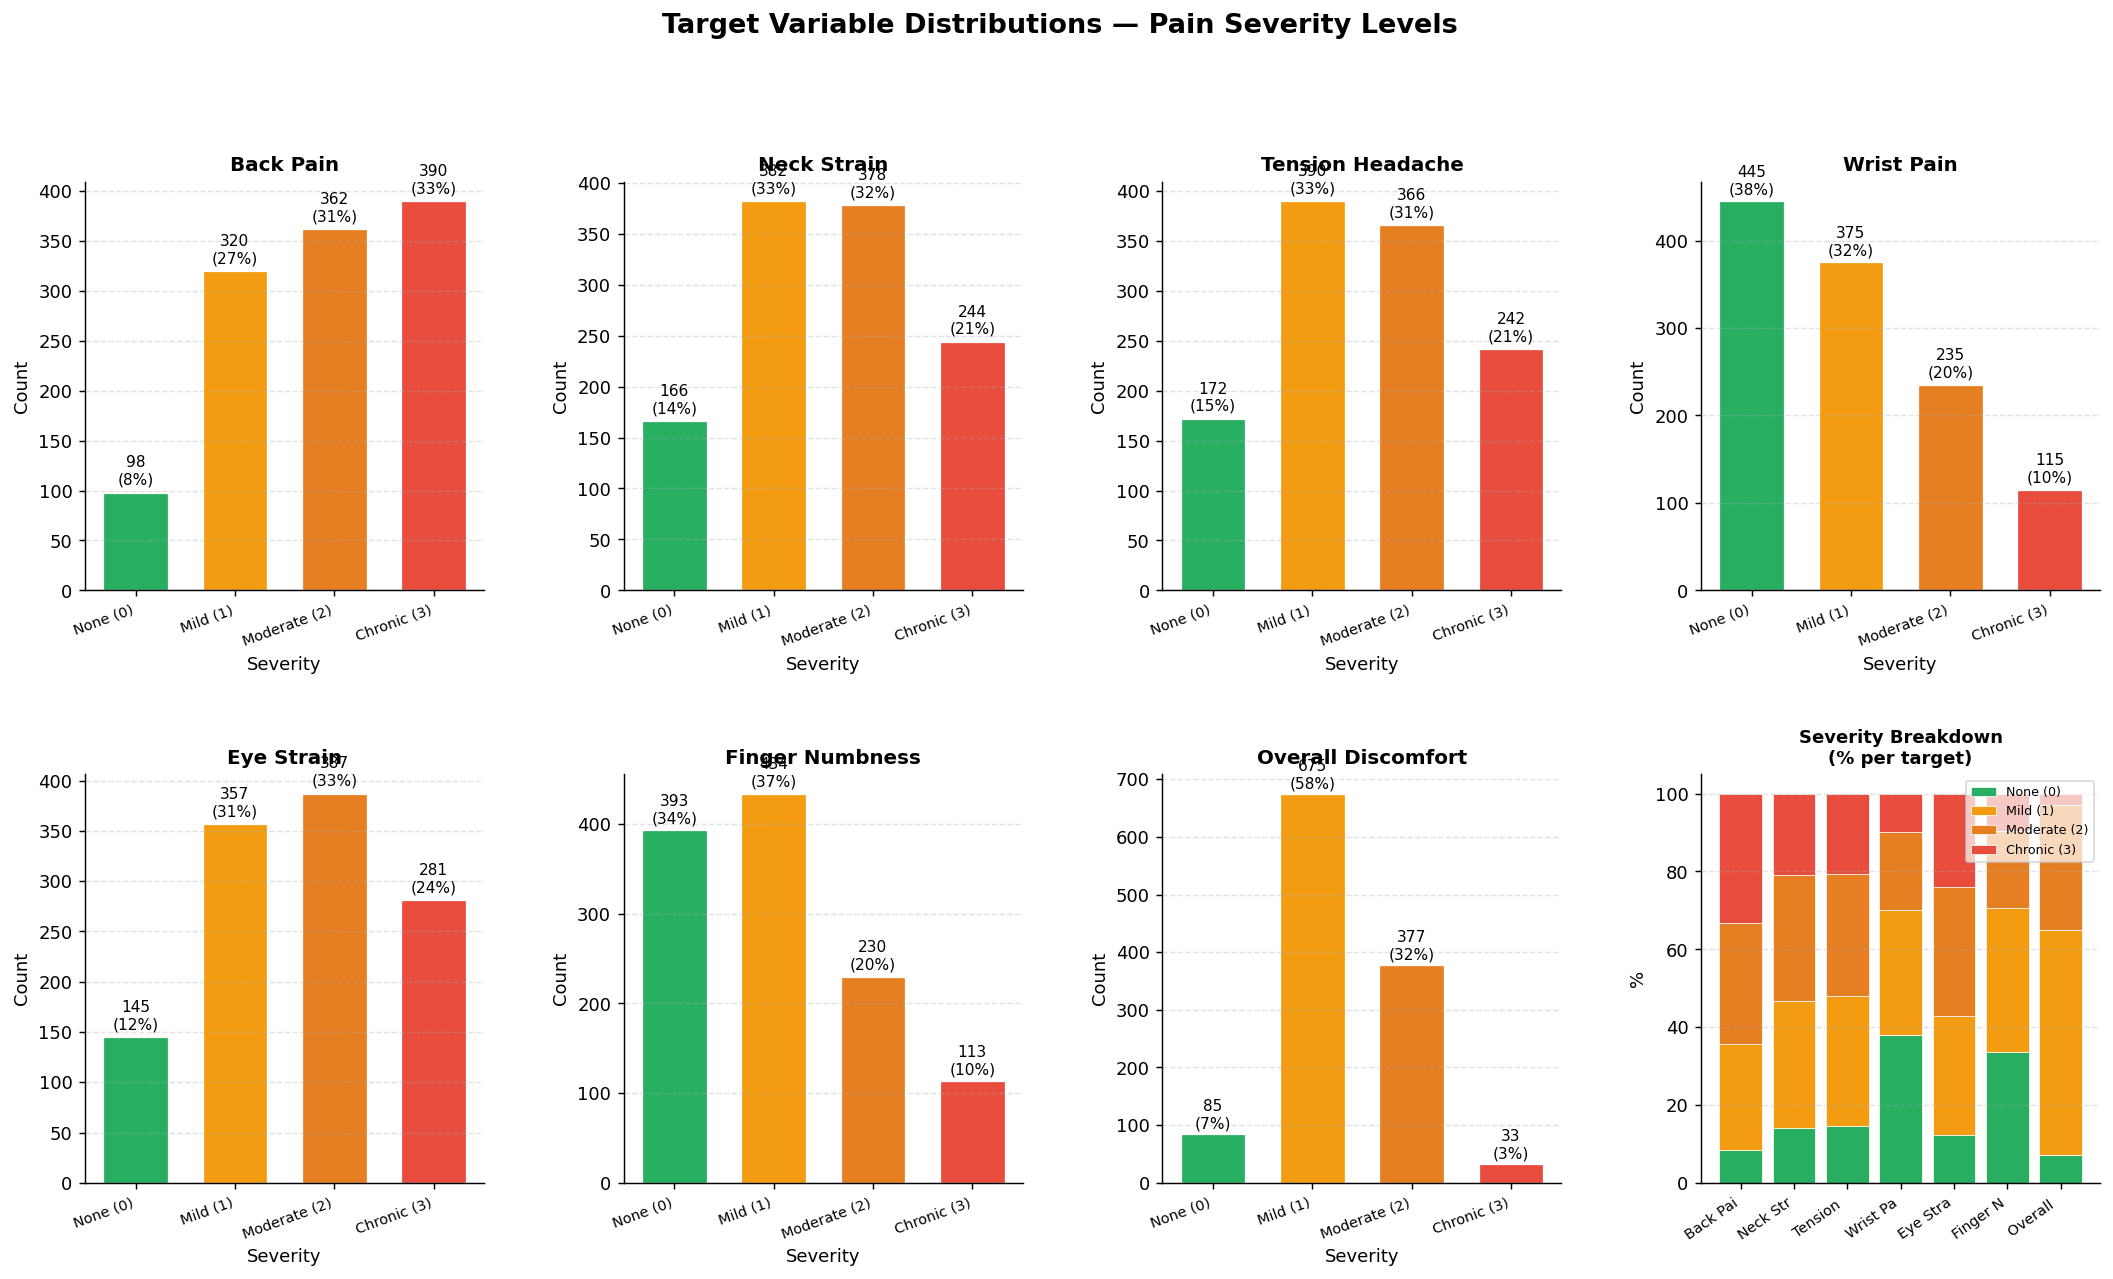

In [99]:
target_nice = {
    'target_back_pain':    'Back Pain',
    'target_neck_strain':  'Neck Strain',
    'target_headache':     'Tension Headache',
    'target_wrist_pain':   'Wrist Pain',
    'target_eye_strain':   'Eye Strain',
    'target_finger_numb':  'Finger Numbness',
    'target_overall':      'Overall Discomfort',
}

fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

for idx, (col, nice) in enumerate(target_nice.items()):
    ax = fig.add_subplot(gs[idx // 4, idx % 4])
    counts = df[col].value_counts().sort_index()
    total  = counts.sum()
    bars = ax.bar(PAIN_LABELS[:len(counts)], counts.values,
                  color=PAIN_COLORS[:len(counts)], edgecolor='white', linewidth=0.7, width=0.65)
    ax.set_title(nice, fontweight='bold', fontsize=11)
    ax.set_xlabel('Severity')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'{v}\n({v/total:.0%})', ha='center', va='bottom', fontsize=8.5)
    ax.set_xticklabels(PAIN_LABELS[:len(counts)], rotation=20, ha='right', fontsize=8)

# Stacked bar: all targets side-by-side
ax_stack = fig.add_subplot(gs[1, 3])
bot = np.zeros(len(target_nice))
for lvl, col_c, lbl in zip([0,1,2,3], PAIN_COLORS, PAIN_LABELS):
    vals = [df[t].value_counts().get(lvl, 0) / len(df) * 100 for t in target_nice]
    ax_stack.bar(range(len(target_nice)), vals, bottom=bot, color=col_c,
                 edgecolor='white', linewidth=0.4, label=lbl)
    bot += np.array(vals)
ax_stack.set_xticks(range(len(target_nice)))
ax_stack.set_xticklabels([n[:8] for n in target_nice.values()], rotation=35, ha='right', fontsize=8)
ax_stack.set_title('Severity Breakdown\n(% per target)', fontweight='bold', fontsize=10)
ax_stack.set_ylabel('%')
ax_stack.legend(fontsize=7, loc='upper right', framealpha=0.7)

plt.suptitle('Target Variable Distributions — Pain Severity Levels', fontsize=15, fontweight='bold', y=1.01)
plt.show()


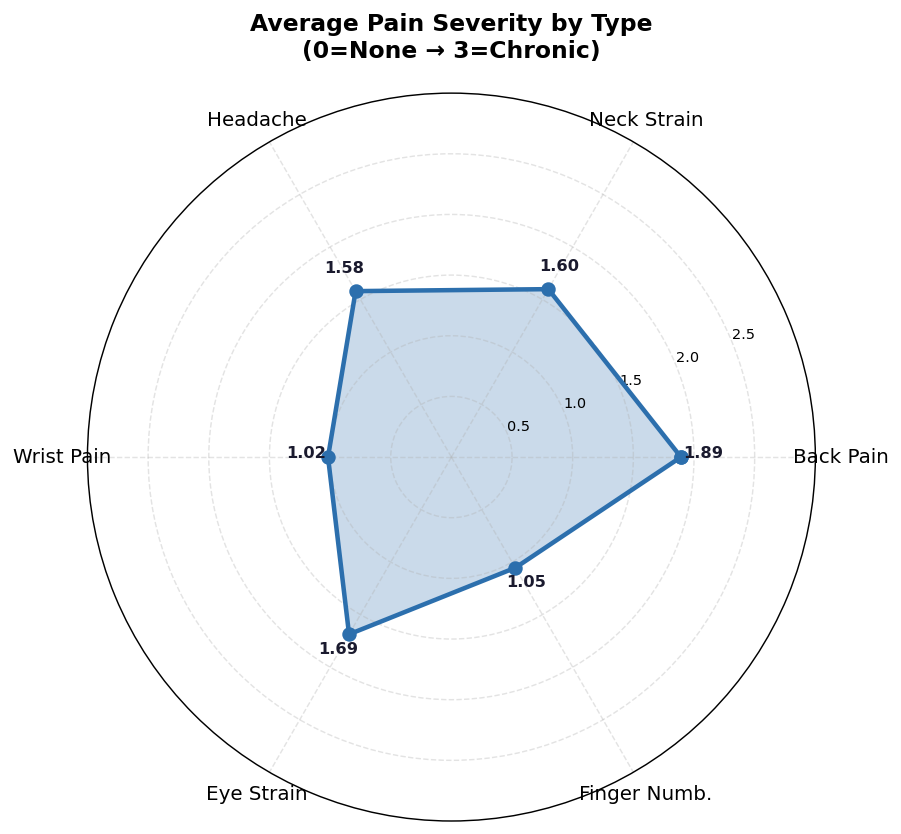

In [100]:
# Radar chart — average pain severity per domain
import matplotlib
fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw=dict(polar=True))

targets_radar = [c for c in TARGET_COLS if c != 'target_overall']
nice_radar = ['Back Pain','Neck Strain','Headache','Wrist Pain','Eye Strain','Finger Numb.']
angles = np.linspace(0, 2*np.pi, len(targets_radar), endpoint=False).tolist()
angles += angles[:1]

means = [df[t].mean() for t in targets_radar]
means_plot = means + means[:1]

ax.fill(angles, means_plot, color=ACCENT, alpha=0.25)
ax.plot(angles, means_plot, color=ACCENT, linewidth=2.5, marker='o', markersize=7)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(nice_radar, fontsize=11)
ax.set_ylim(0, 3)
ax.set_yticks([0.5, 1.0, 1.5, 2.0, 2.5])
ax.set_yticklabels(['0.5','1.0','1.5','2.0','2.5'], fontsize=8)
ax.set_title('Average Pain Severity by Type\n(0=None → 3=Chronic)', fontsize=13,
             fontweight='bold', pad=20)

# Annotate
for angle, val, lbl in zip(angles[:-1], means, nice_radar):
    ax.annotate(f'{val:.2f}', xy=(angle, val), xytext=(angle, val+0.18),
                ha='center', fontsize=9, color='#1a1a2e', fontweight='bold')

plt.tight_layout()
plt.show()


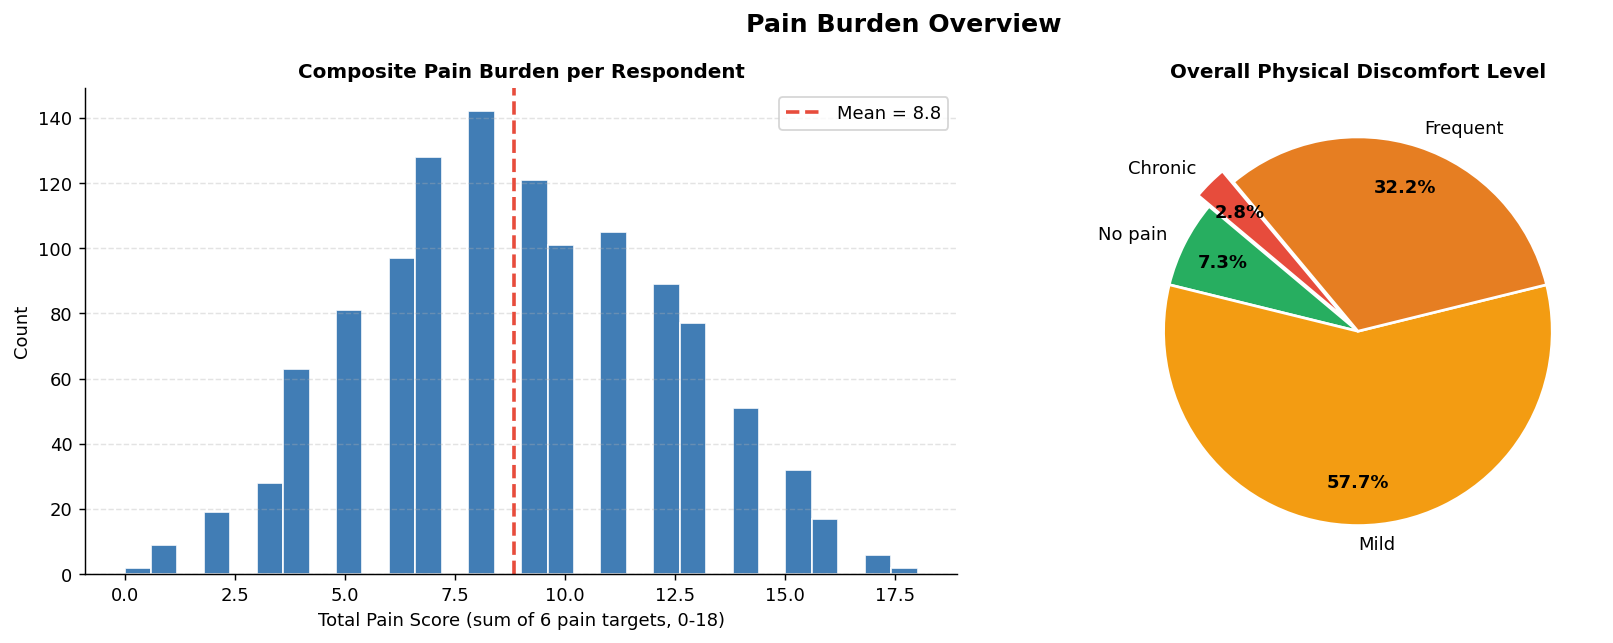

In [101]:
# Composite pain burden per respondent
df['total_pain_score'] = df[targets_radar].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_pain_score'], bins=30, color=ACCENT, edgecolor='white', alpha=0.9)
axes[0].axvline(df['total_pain_score'].mean(), color='#e74c3c', lw=2, linestyle='--',
                label=f"Mean = {df['total_pain_score'].mean():.1f}")
axes[0].set_title('Composite Pain Burden per Respondent', fontweight='bold')
axes[0].set_xlabel('Total Pain Score (sum of 6 pain targets, 0-18)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Pie: overall discomfort level
overall_counts = df['target_overall'].value_counts().sort_index()
overall_labels = ['No pain','Mild','Frequent','Chronic']
explode = [0, 0, 0, 0.08]
wedges, texts, autotexts = axes[1].pie(
    overall_counts.values, labels=overall_labels,
    colors=PAIN_COLORS[:len(overall_counts)],
    autopct='%1.1f%%', startangle=140, explode=explode,
    textprops={'fontsize': 10}, pctdistance=0.78,
    wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Overall Physical Discomfort Level', fontweight='bold')

plt.suptitle('Pain Burden Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Bivariate Analysis — Features vs Pain Targets

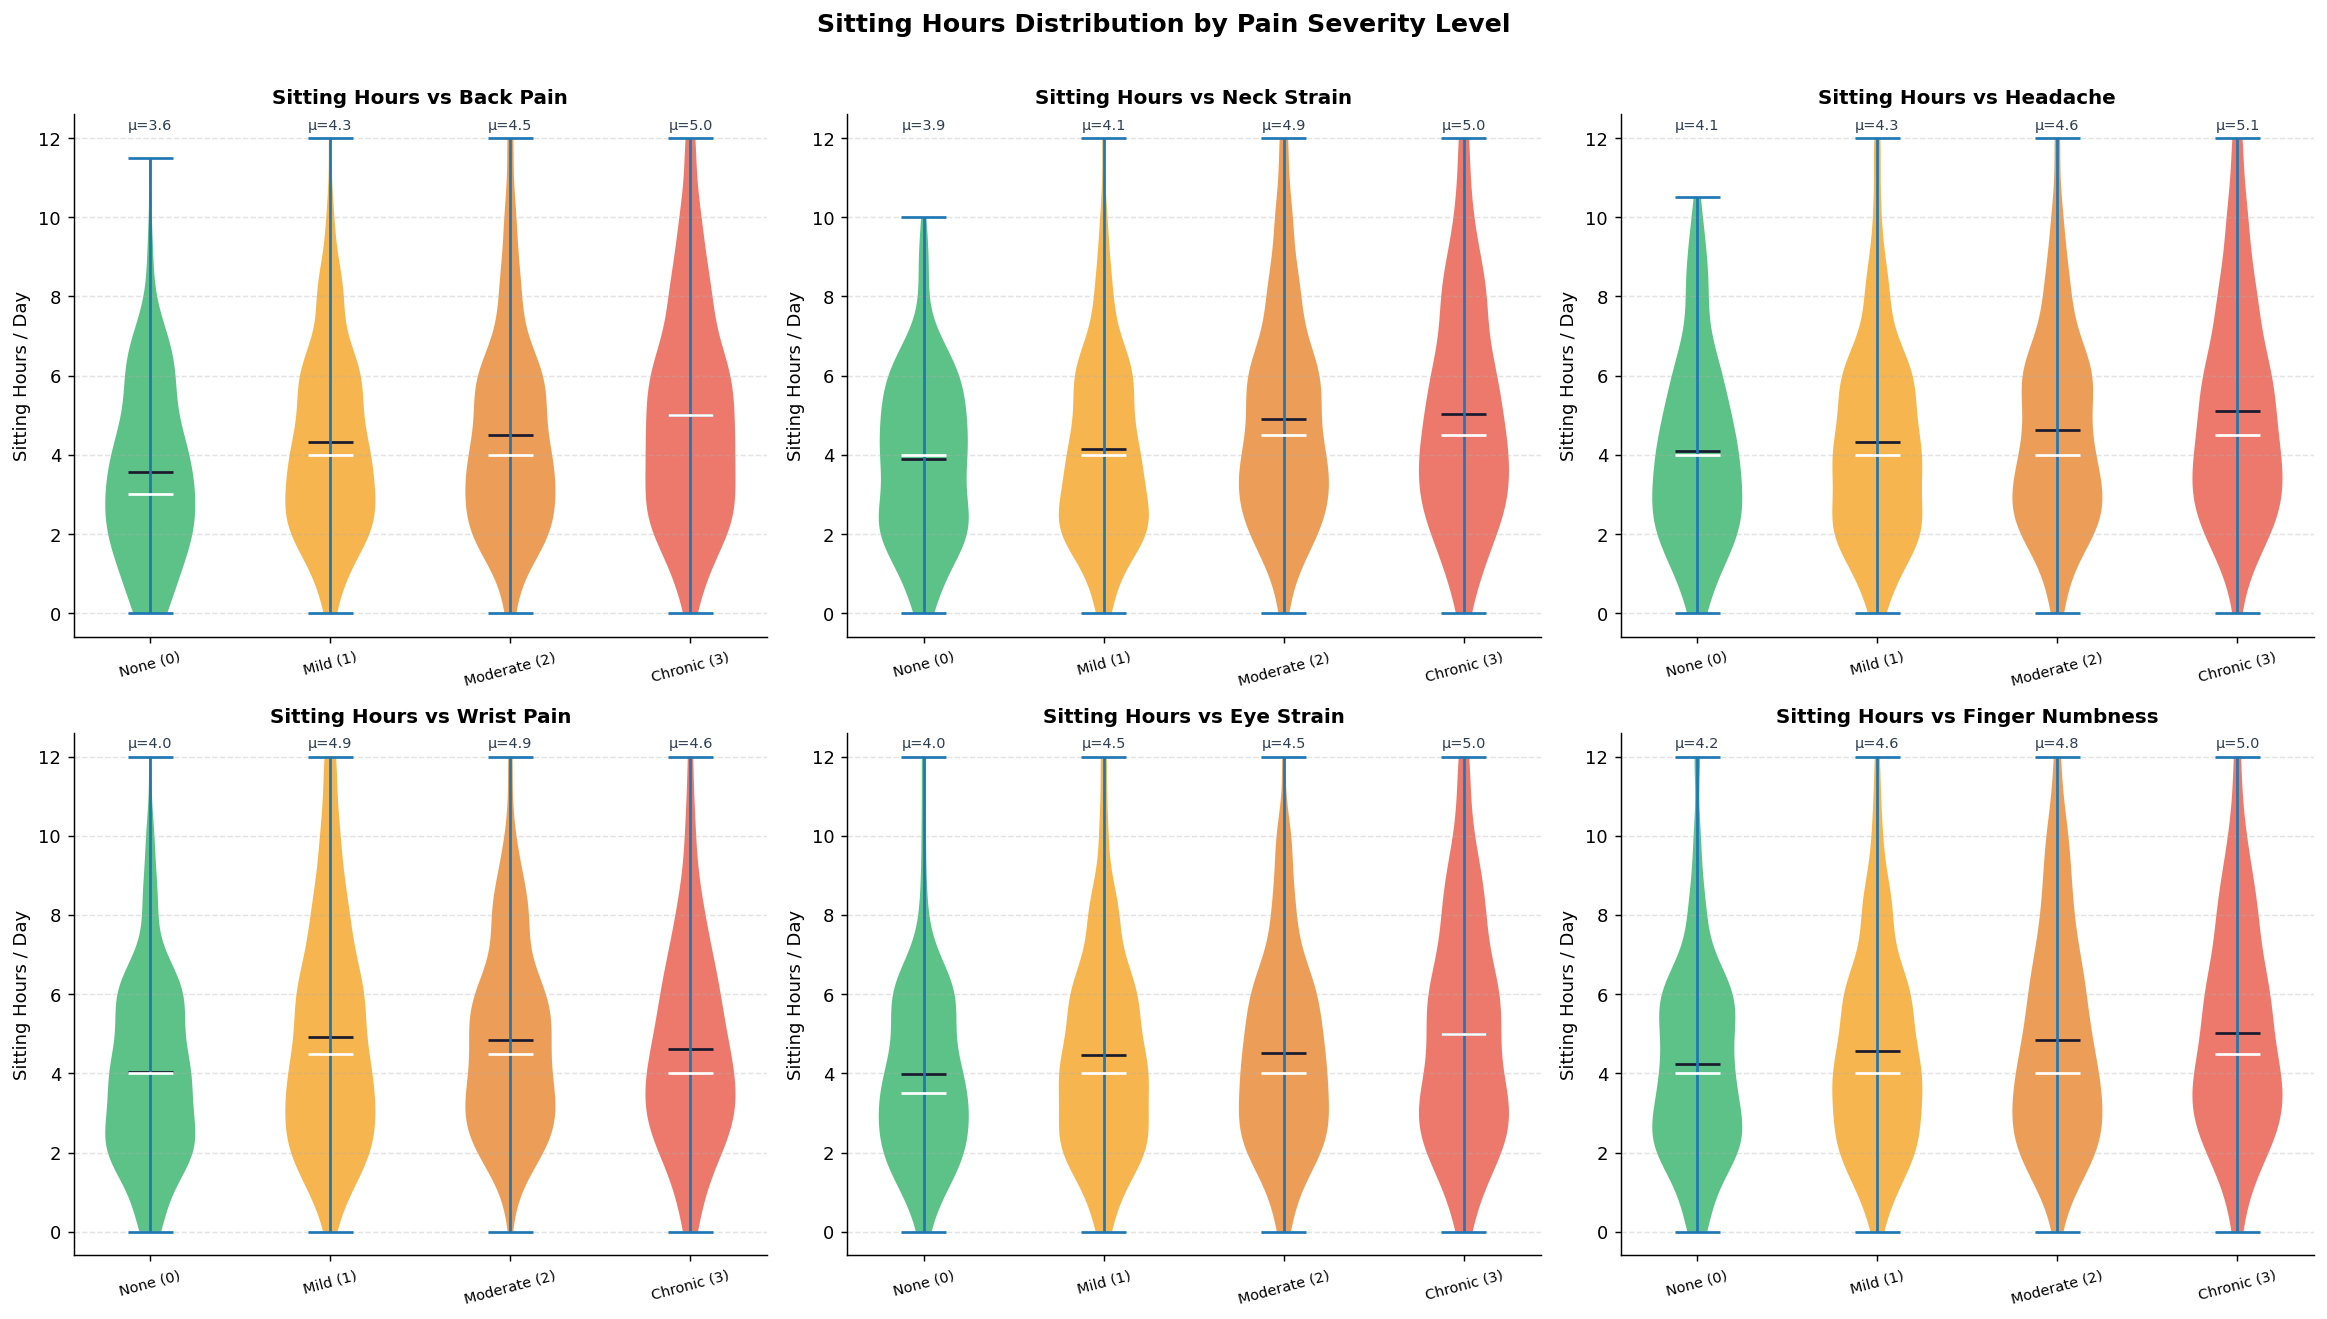

In [102]:
# ── 5.1 Sitting hours vs each pain target (violin plots) ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
pain_targets = [c for c in TARGET_COLS if c != 'target_overall']
target_nice_list = ['Back Pain','Neck Strain','Headache','Wrist Pain','Eye Strain','Finger Numbness']

for ax, col, nice in zip(axes, pain_targets, target_nice_list):
    data_by_level = [df.loc[df[col]==lvl, 'sitting_hours'].values for lvl in range(4)]
    parts = ax.violinplot(data_by_level, positions=range(4),
                          showmeans=True, showmedians=True)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(PAIN_COLORS[j])
        pc.set_alpha(0.75)
    parts['cmeans'].set_color('#1a1a2e')
    parts['cmedians'].set_color('white')
    ax.set_xticks(range(4))
    ax.set_xticklabels(PAIN_LABELS, fontsize=8, rotation=15)
    ax.set_title(f'Sitting Hours vs {nice}', fontweight='bold')
    ax.set_ylabel('Sitting Hours / Day')
    # means
    for lvl in range(4):
        m = df.loc[df[col]==lvl, 'sitting_hours'].mean()
        ax.text(lvl, ax.get_ylim()[1]*0.97, f'μ={m:.1f}',
                ha='center', fontsize=8, color='#2c3e50')

plt.suptitle('Sitting Hours Distribution by Pain Severity Level', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


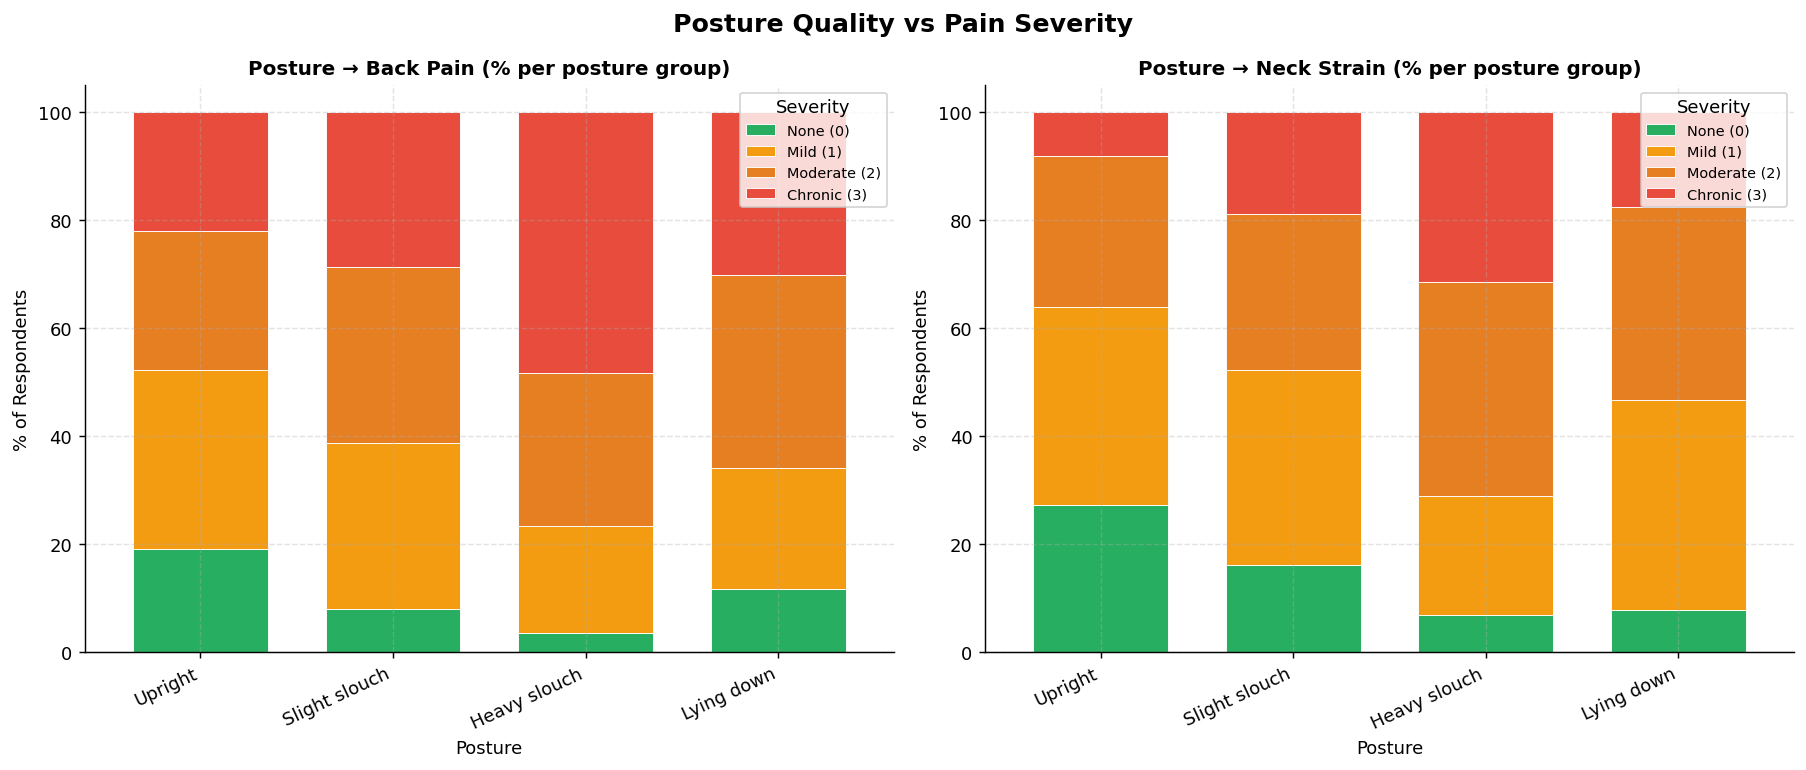

In [103]:
# ── 5.2 Posture vs Back Pain & Neck Strain ───────────────────────────────────
posture_labels  = {0:'Upright',1:'Slight slouch',2:'Heavy slouch',3:'Lying down'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tcol, nice in zip(axes,
                           ['target_back_pain','target_neck_strain'],
                           ['Back Pain','Neck Strain']):
    ct = pd.crosstab(df['posture'], df[tcol], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=PAIN_COLORS, edgecolor='white', linewidth=0.5, width=0.7)
    ax.set_xticklabels([posture_labels[int(x.get_text())] for x in ax.get_xticklabels()],
                        rotation=25, ha='right')
    ax.set_title(f'Posture → {nice} (% per posture group)', fontweight='bold')
    ax.set_xlabel('Posture')
    ax.set_ylabel('% of Respondents')
    ax.legend(PAIN_LABELS, title='Severity', fontsize=8, loc='upper right')

plt.suptitle('Posture Quality vs Pain Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


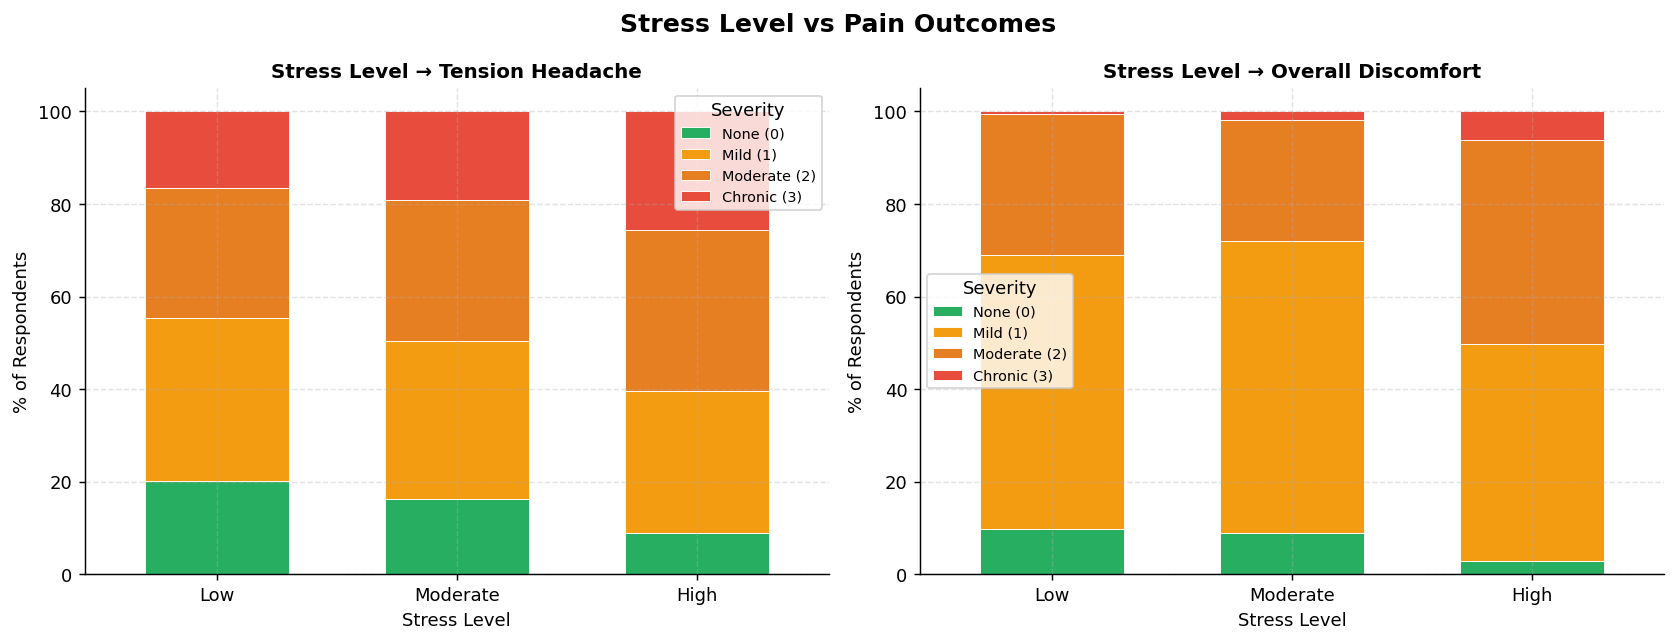

In [104]:
# ── 5.3 Stress level vs Headache & Overall ───────────────────────────────────
stress_labels = {0:'Low',1:'Moderate',2:'High'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tcol, nice in zip(axes,
                            ['target_headache','target_overall'],
                            ['Tension Headache','Overall Discomfort']):
    ct = pd.crosstab(df['stress_level'], df[tcol], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=PAIN_COLORS, edgecolor='white', linewidth=0.5, width=0.6)
    ax.set_xticklabels([stress_labels[int(x.get_text())] for x in ax.get_xticklabels()],
                        rotation=0)
    ax.set_title(f'Stress Level → {nice}', fontweight='bold')
    ax.set_xlabel('Stress Level')
    ax.set_ylabel('% of Respondents')
    ax.legend(PAIN_LABELS, title='Severity', fontsize=8)

plt.suptitle('Stress Level vs Pain Outcomes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


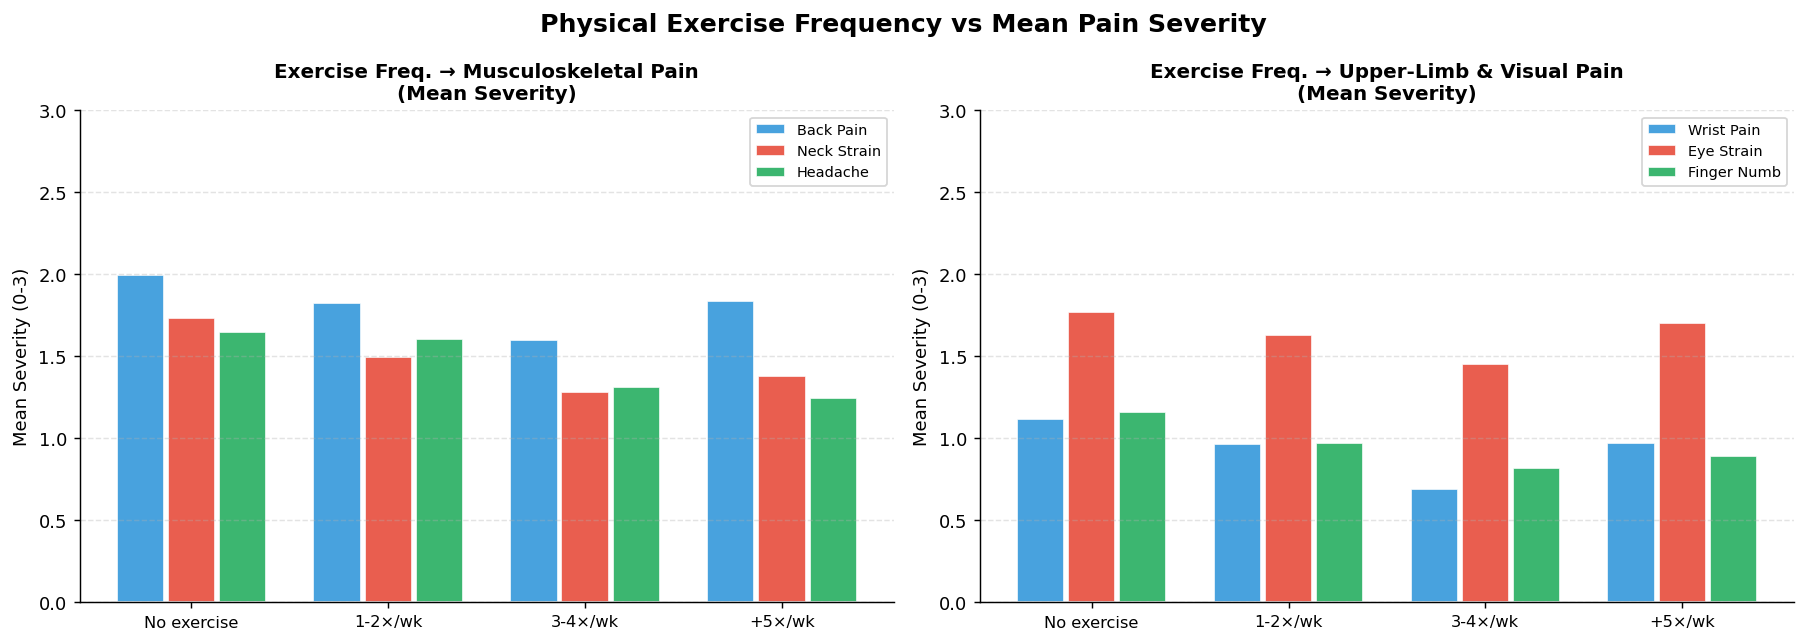

In [105]:
# ── 5.4 Exercise frequency vs pain (grouped bar — mean severity) ─────────────
exercise_labels = {0:'No exercise',1:'1-2×/wk',2:'3-4×/wk',3:'+5×/wk'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, targets, title in zip(
        axes,
        [['target_back_pain','target_neck_strain','target_headache'],
         ['target_wrist_pain','target_eye_strain','target_finger_numb']],
        ['Musculoskeletal Pain', 'Upper-Limb & Visual Pain']):

    for i, tcol in enumerate(targets):
        means = df.groupby('exercise_freq')[tcol].mean()
        x = np.arange(len(means))
        offset = (i - 1) * 0.26
        label = tcol.replace('target_','').replace('_',' ').title()
        ax.bar(x + offset, means.values, width=0.24,
               color=['#3498db','#e74c3c','#27ae60'][i],
               edgecolor='white', label=label, alpha=0.9)

    ax.set_xticks(range(len(means)))
    ax.set_xticklabels([exercise_labels[k] for k in means.index], fontsize=9)
    ax.set_title(f'Exercise Freq. → {title}\n(Mean Severity)', fontweight='bold')
    ax.set_ylabel('Mean Severity (0-3)')
    ax.set_ylim(0, 3)
    ax.legend(fontsize=8)

plt.suptitle('Physical Exercise Frequency vs Mean Pain Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


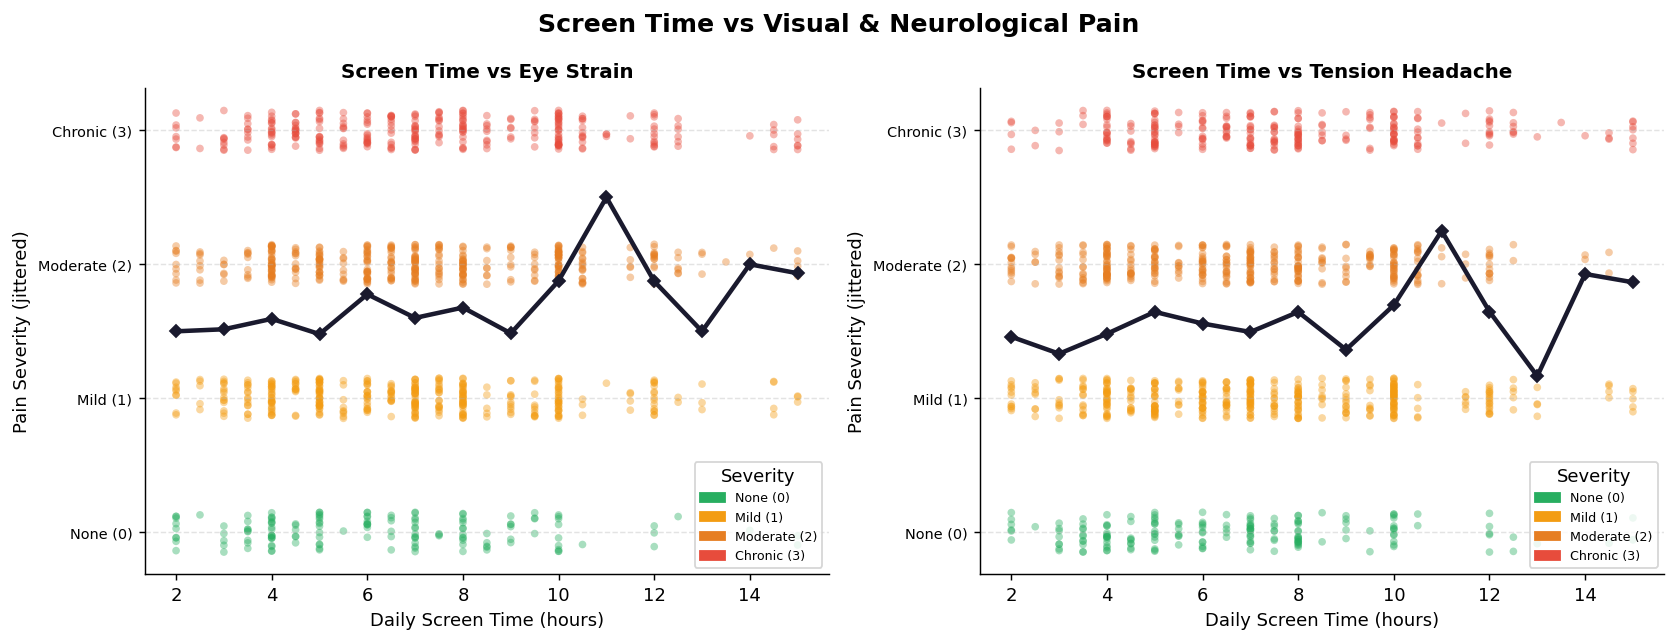

In [106]:
# ── 5.5 Screen time vs Eye Strain & Headache (scatter + regression) ──────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tcol, nice in zip(axes,
                            ['target_eye_strain','target_headache'],
                            ['Eye Strain','Tension Headache']):
    # Jitter for visibility
    jitter = np.random.uniform(-0.15, 0.15, len(df))
    scatter_colors = [PAIN_COLORS[v] for v in df[tcol]]
    ax.scatter(df['screen_time'], df[tcol] + jitter,
               c=scatter_colors, alpha=0.4, s=18, linewidths=0)
    # Mean per integer screen time
    grouped = df.groupby(df['screen_time'].round(0))[tcol].mean().reset_index()
    ax.plot(grouped['screen_time'], grouped[tcol], color='#1a1a2e',
            linewidth=2.5, marker='D', markersize=5, zorder=5, label='Group mean')
    ax.set_xlabel('Daily Screen Time (hours)')
    ax.set_ylabel('Pain Severity (jittered)')
    ax.set_yticks([0,1,2,3])
    ax.set_yticklabels(PAIN_LABELS, fontsize=8)
    ax.set_title(f'Screen Time vs {nice}', fontweight='bold')
    legend_patches = [mpatches.Patch(color=c, label=l) for c,l in zip(PAIN_COLORS, PAIN_LABELS)]
    ax.legend(handles=legend_patches, fontsize=7, title='Severity')

plt.suptitle('Screen Time vs Visual & Neurological Pain', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


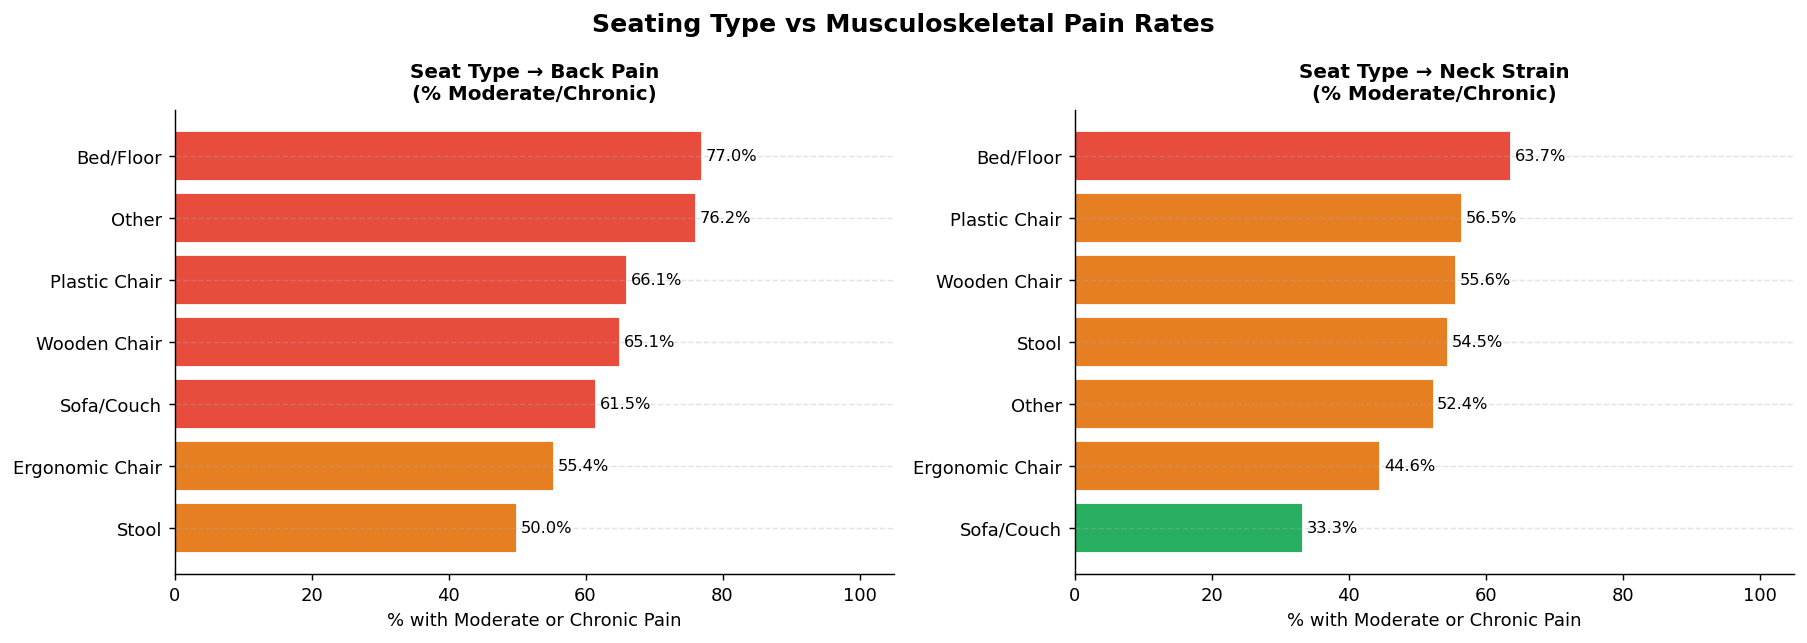

In [107]:
# ── 5.6 Seat type vs Back Pain (horizontal bar — % chronic+moderate) ─────────
seat_cols_ohe  = [c for c in df.columns if c.startswith('seat_type_')]
seat_nice = {
    'seat_type_ergonomic_office_chair_with_back_support': 'Ergonomic Chair',
    'seat_type_wooden_chair':   'Wooden Chair',
    'seat_type_plastic_chair_standard': 'Plastic Chair',
    'seat_type_sofa_couch':     'Sofa/Couch',
    'seat_type_stool_no_backrest': 'Stool',
    'seat_type_bed_floor_no_chair': 'Bed/Floor',
    'seat_type_other':          'Other',
}

# Reconstruct seat type column
df['seat_type_label'] = 'Other'
for sc in seat_cols_ohe:
    mask = df[sc] == 1
    df.loc[mask, 'seat_type_label'] = seat_nice.get(sc, sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tcol, nice in zip(axes,
                           ['target_back_pain','target_neck_strain'],
                           ['Back Pain','Neck Strain']):
    pain_by_seat = df.groupby('seat_type_label')[tcol].apply(
        lambda x: (x >= 2).mean() * 100).sort_values(ascending=True)
    colors_bar = ['#e74c3c' if v > 60 else '#e67e22' if v > 40 else '#27ae60'
                  for v in pain_by_seat.values]
    ax.barh(pain_by_seat.index, pain_by_seat.values, color=colors_bar, edgecolor='white')
    for i, v in enumerate(pain_by_seat.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('% with Moderate or Chronic Pain')
    ax.set_title(f'Seat Type → {nice}\n(% Moderate/Chronic)', fontweight='bold')
    ax.set_xlim(0, 105)

plt.suptitle('Seating Type vs Musculoskeletal Pain Rates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
df.drop(columns=['seat_type_label'], inplace=True)


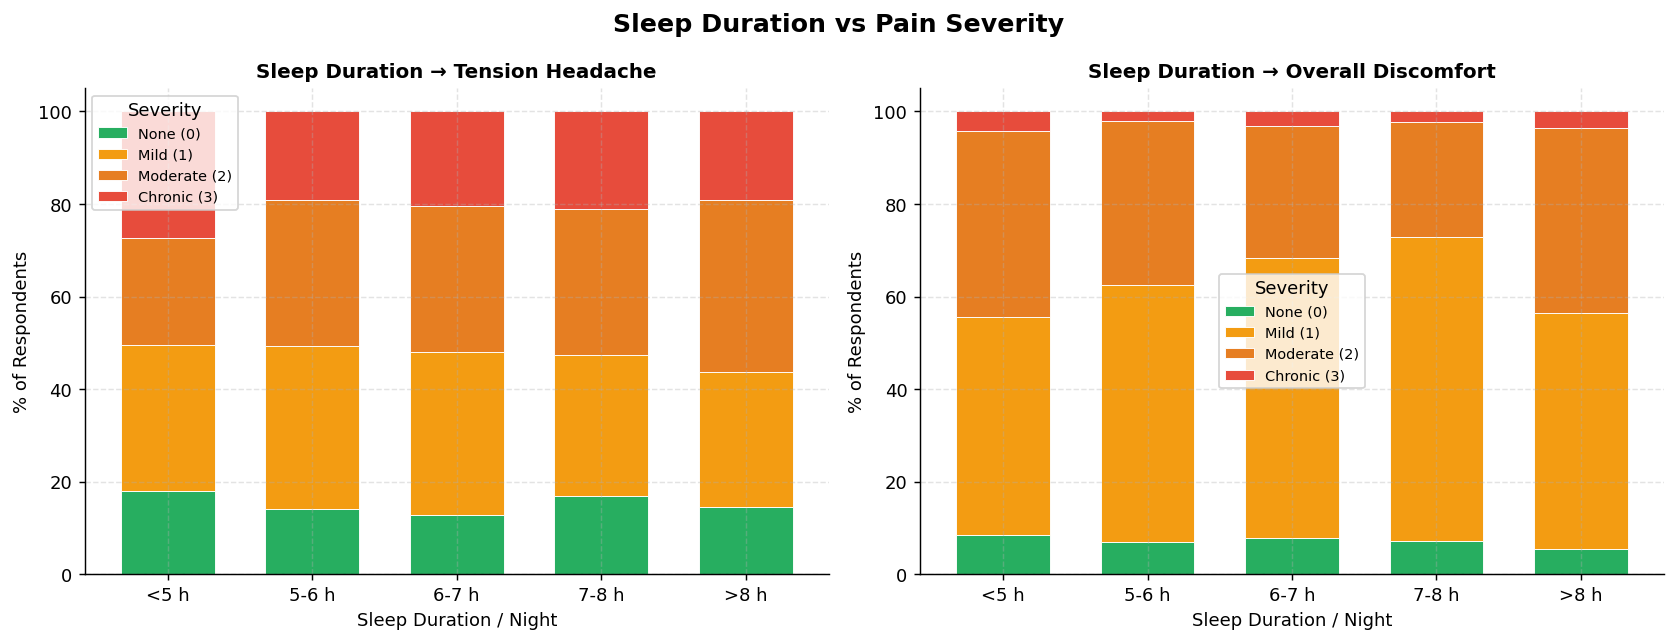

In [108]:
# ── 5.7 Sleep duration vs overall pain & headache ────────────────────────────
sleep_labels = {0:'<5 h',1:'5-6 h',2:'6-7 h',3:'7-8 h',4:'>8 h'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tcol, nice in zip(axes,
                           ['target_headache','target_overall'],
                           ['Tension Headache','Overall Discomfort']):
    ct = pd.crosstab(df['sleep_duration'], df[tcol], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=PAIN_COLORS, edgecolor='white', linewidth=0.5, width=0.65)
    ax.set_xticklabels([sleep_labels[int(x.get_text())] for x in ax.get_xticklabels()], rotation=0)
    ax.set_title(f'Sleep Duration → {nice}', fontweight='bold')
    ax.set_xlabel('Sleep Duration / Night')
    ax.set_ylabel('% of Respondents')
    ax.legend(PAIN_LABELS, title='Severity', fontsize=8)

plt.suptitle('Sleep Duration vs Pain Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


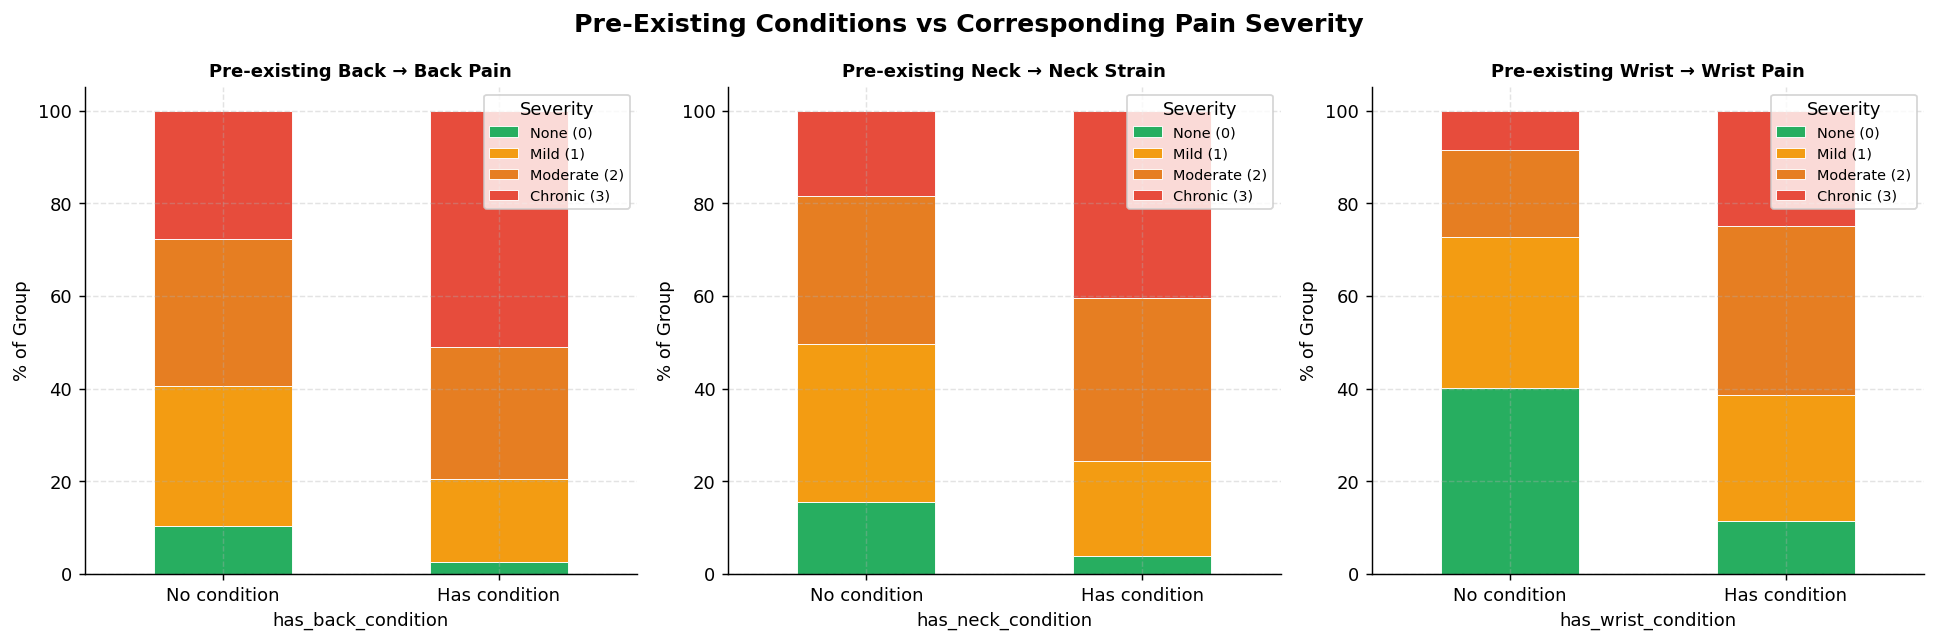

In [109]:
# ── 5.8 Pre-existing conditions vs corresponding pain targets ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    ('has_back_condition',  'target_back_pain',   'Pre-existing Back → Back Pain'),
    ('has_neck_condition',  'target_neck_strain',  'Pre-existing Neck → Neck Strain'),
    ('has_wrist_condition', 'target_wrist_pain',   'Pre-existing Wrist → Wrist Pain'),
]
cond_labels = {0: 'No condition', 1: 'Has condition'}

for ax, (cond_col, pain_col, title) in zip(axes, pairs):
    ct = pd.crosstab(df[cond_col], df[pain_col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=PAIN_COLORS, edgecolor='white', linewidth=0.5, width=0.5)
    ax.set_xticklabels([cond_labels[int(x.get_text())] for x in ax.get_xticklabels()], rotation=0)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('% of Group')
    ax.legend(PAIN_LABELS, title='Severity', fontsize=8)

plt.suptitle('Pre-Existing Conditions vs Corresponding Pain Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


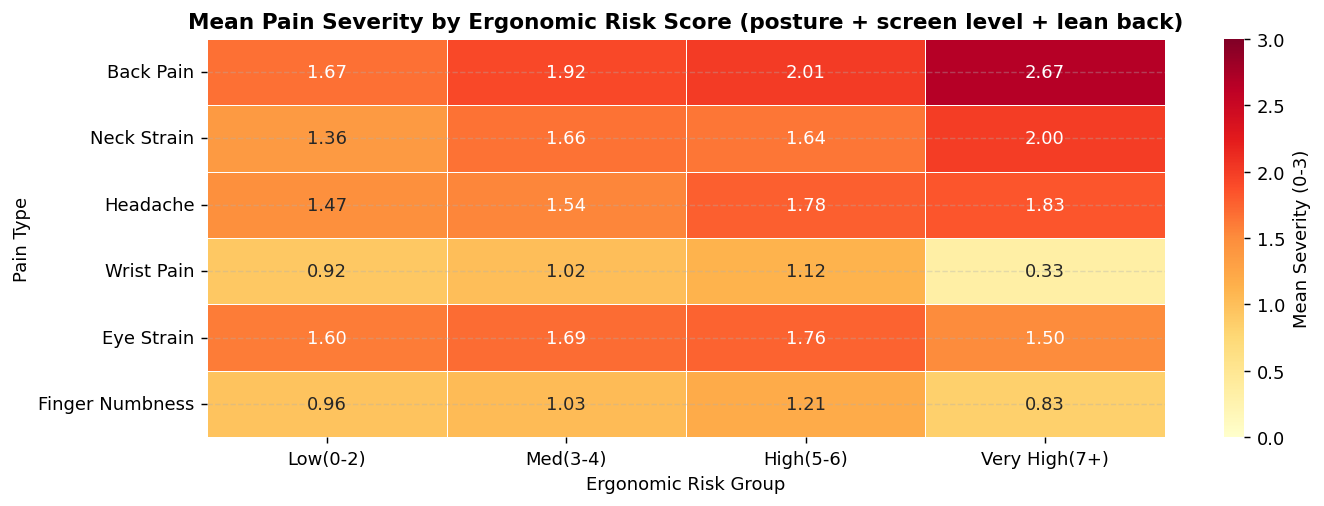

In [110]:
# ── 5.9 Ergonomic risk score vs all pain targets (heatmap of means) ──────────
erg_bins   = pd.cut(df['ergonomic_risk'], bins=[-0.5,2,4,6,8], labels=['Low(0-2)','Med(3-4)','High(5-6)','Very High(7+)'])
means_mat  = pd.DataFrame({nice: df.groupby(erg_bins)[col].mean()
                            for col, nice in zip(pain_targets, target_nice_list)})

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(means_mat.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=3,
            cbar_kws={'label':'Mean Severity (0-3)'})
ax.set_title('Mean Pain Severity by Ergonomic Risk Score (posture + screen level + lean back)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Ergonomic Risk Group')
ax.set_ylabel('Pain Type')
plt.tight_layout()
plt.show()


## 6. Correlation & Association Analysis

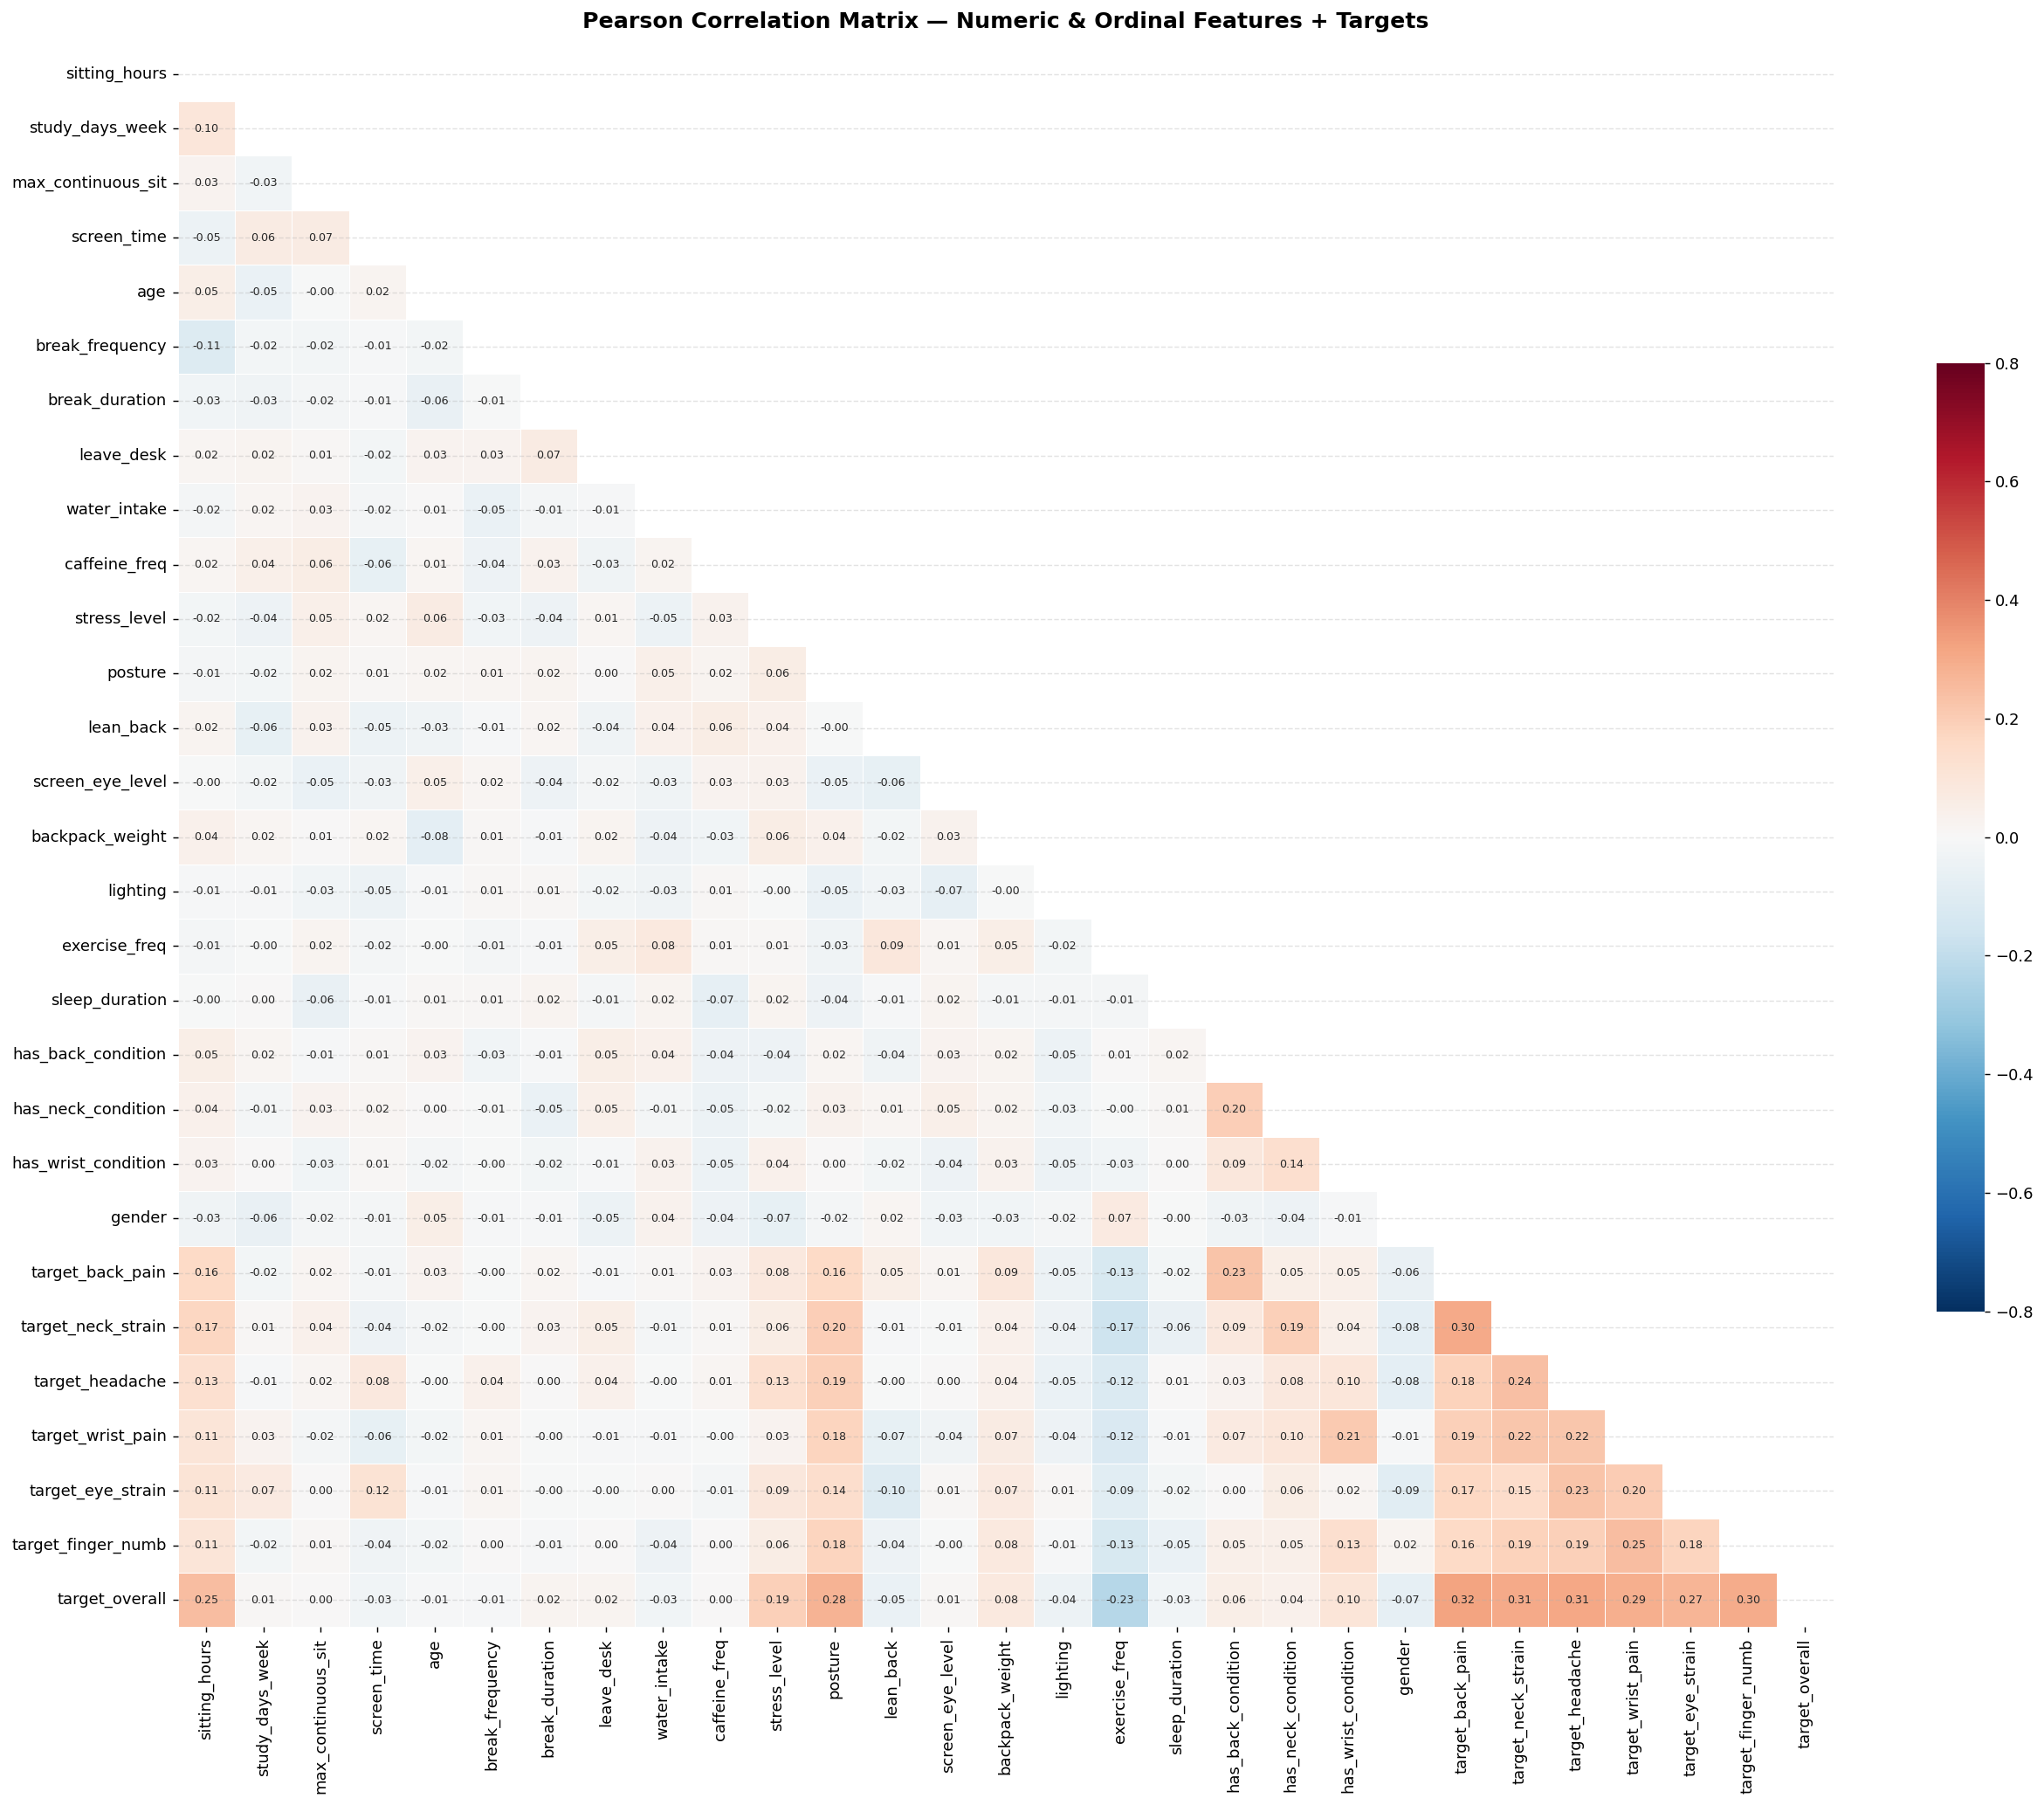

In [111]:
# ── 6.1 Full correlation matrix (numeric + ordinal features only) ─────────────
corr_cols = NUMERIC_FEATS + ORDINAL_FEATS + ['has_back_condition','has_neck_condition','has_wrist_condition',
                                               'gender'] + TARGET_COLS
corr_mat = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-0.8, vmax=0.8, linewidths=0.3, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.6})
ax.set_title('Pearson Correlation Matrix — Numeric & Ordinal Features + Targets',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


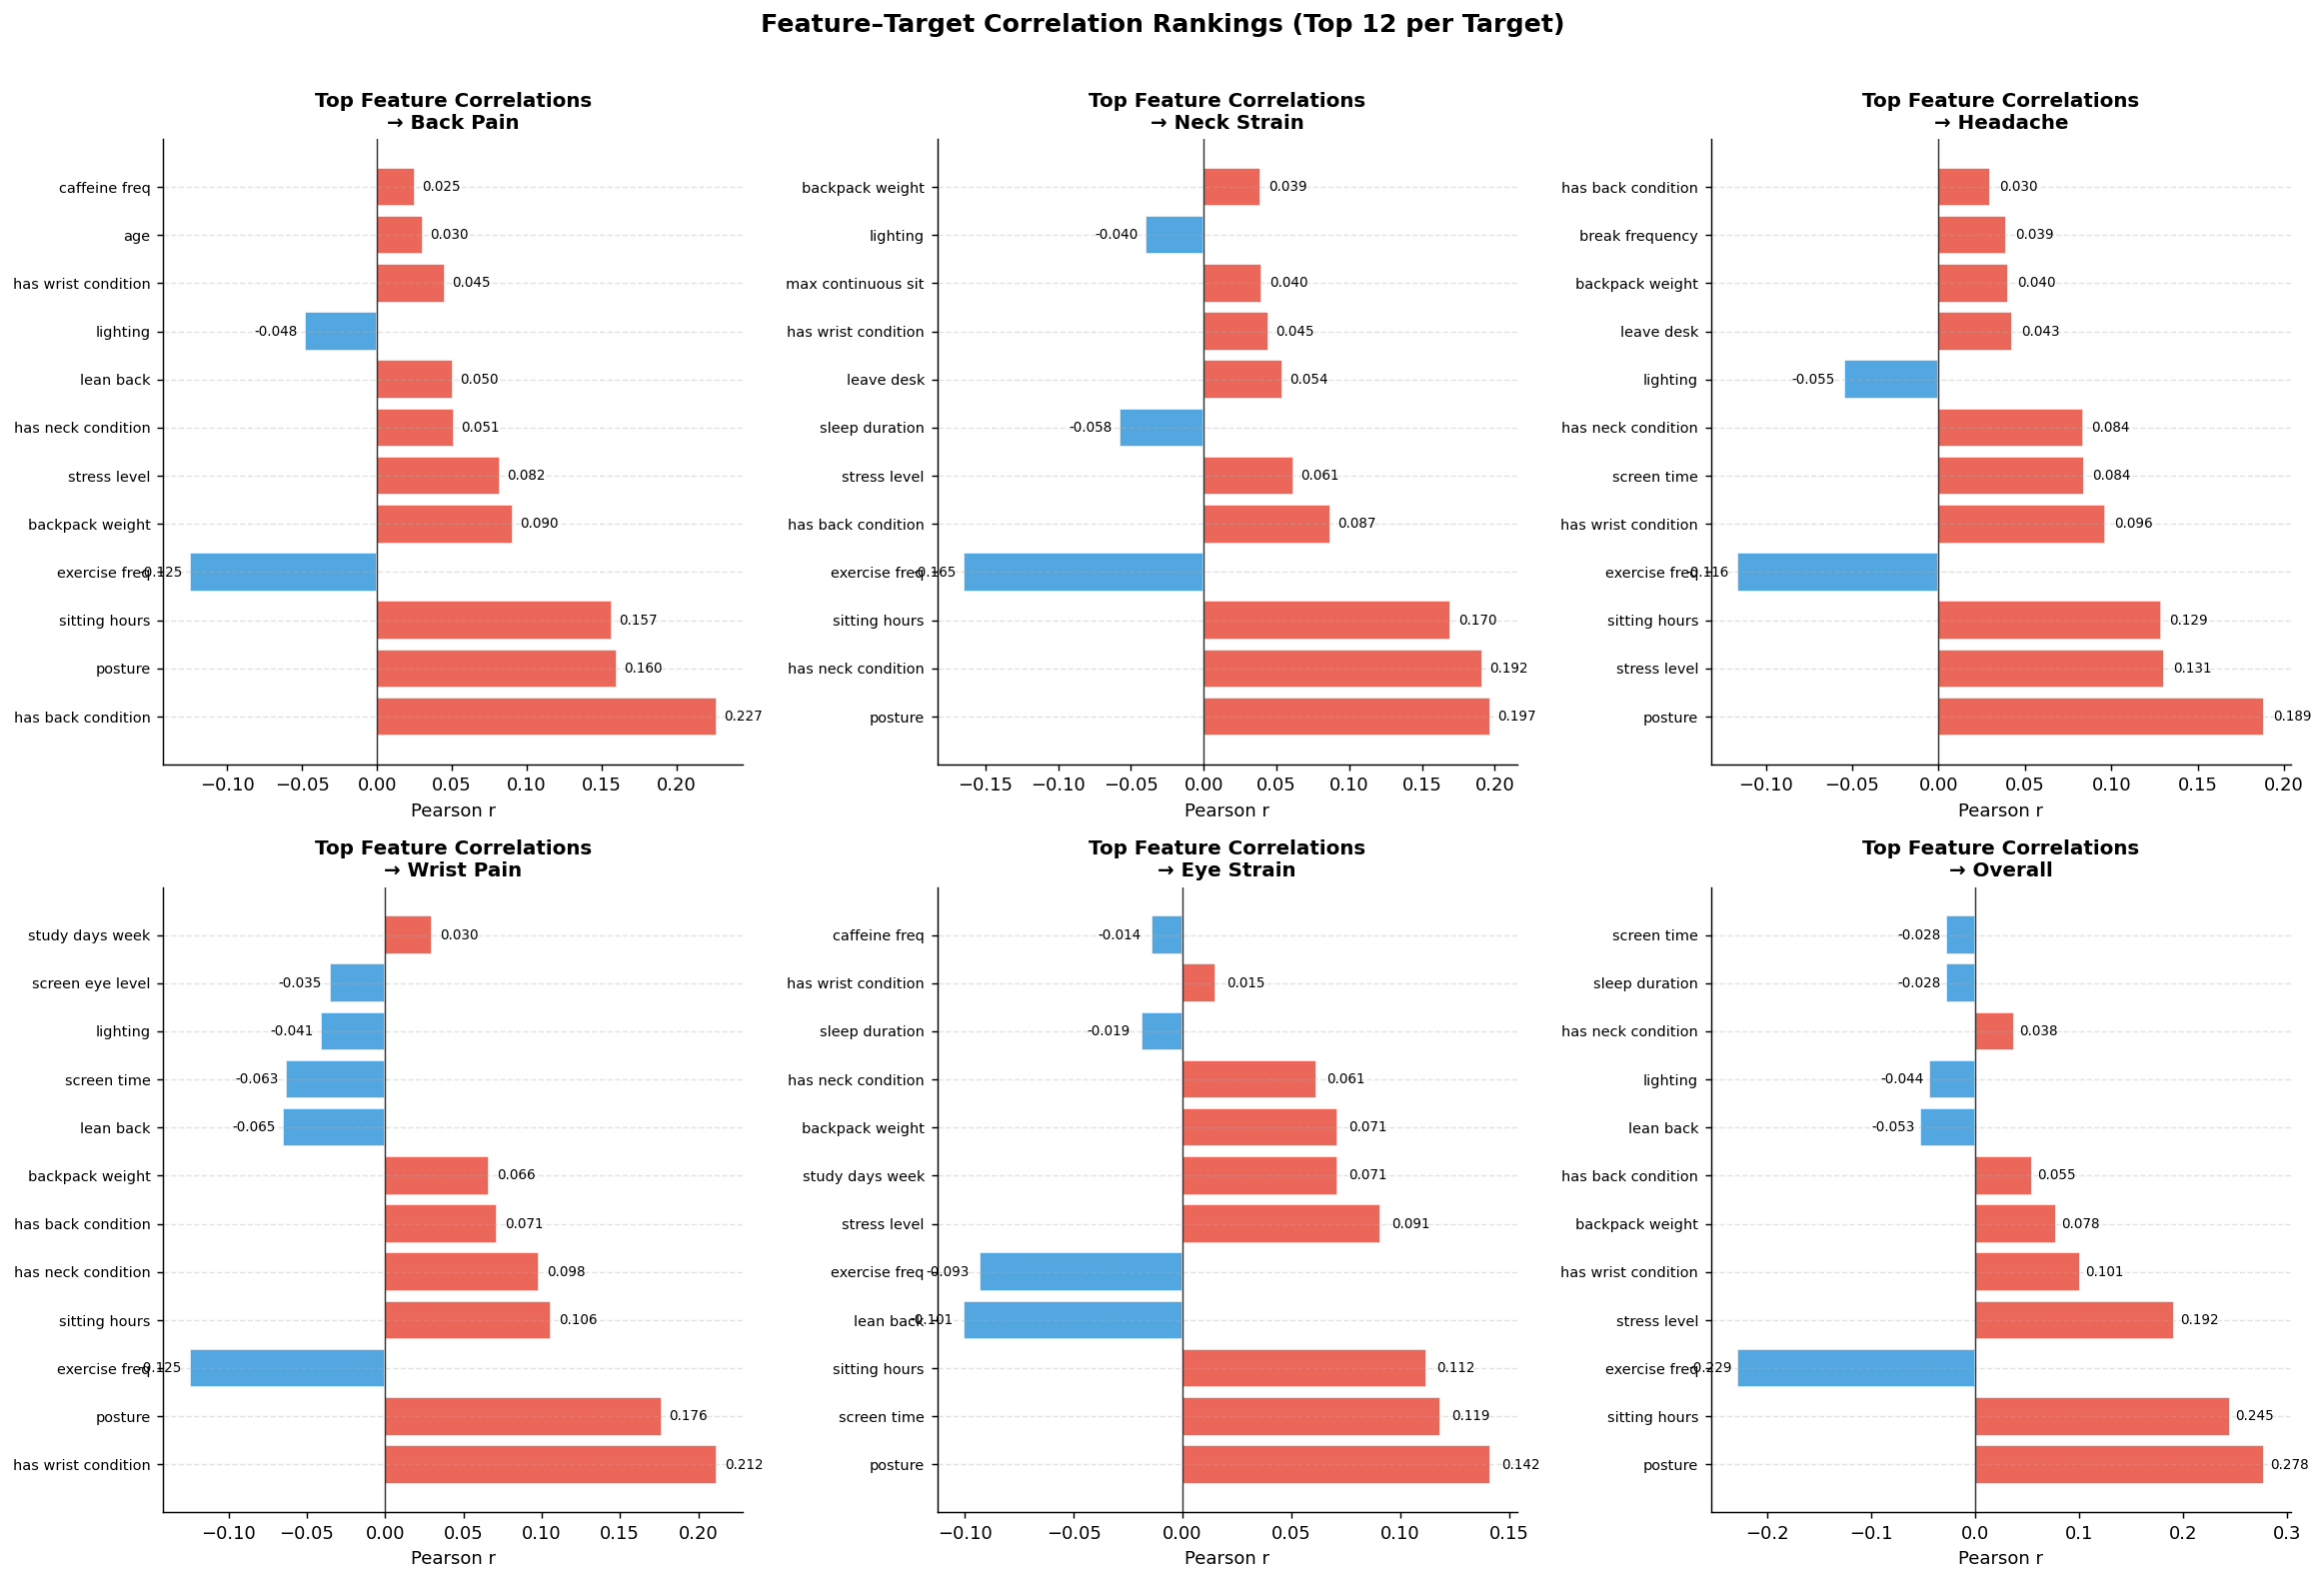

In [112]:
# ── 6.2 Feature–target correlations (bar chart, ranked) ──────────────────────
analysis_cols = NUMERIC_FEATS + ORDINAL_FEATS + ['has_back_condition','has_neck_condition','has_wrist_condition']
main_targets  = ['target_back_pain','target_neck_strain','target_headache',
                 'target_wrist_pain','target_eye_strain','target_overall']
nice_map = {
    'target_back_pain':'Back Pain','target_neck_strain':'Neck Strain',
    'target_headache':'Headache','target_wrist_pain':'Wrist Pain',
    'target_eye_strain':'Eye Strain','target_overall':'Overall',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, tcol in zip(axes, main_targets):
    corrs = df[analysis_cols].corrwith(df[tcol]).abs().sort_values(ascending=False).head(12)
    raw   = df[analysis_cols].corrwith(df[tcol]).reindex(corrs.index)
    colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in raw.values]
    bars = ax.barh(range(len(corrs)), raw.values, color=colors_bar, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(corrs)))
    ax.set_yticklabels([c.replace('_',' ') for c in corrs.index], fontsize=8)
    ax.axvline(0, color='#333', lw=0.8)
    ax.set_title(f'Top Feature Correlations\n→ {nice_map[tcol]}', fontweight='bold')
    ax.set_xlabel('Pearson r')
    for i, v in enumerate(raw.values):
        ax.text(v + (0.005 if v >= 0 else -0.005), i,
                f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=7.5)

plt.suptitle('Feature–Target Correlation Rankings (Top 12 per Target)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


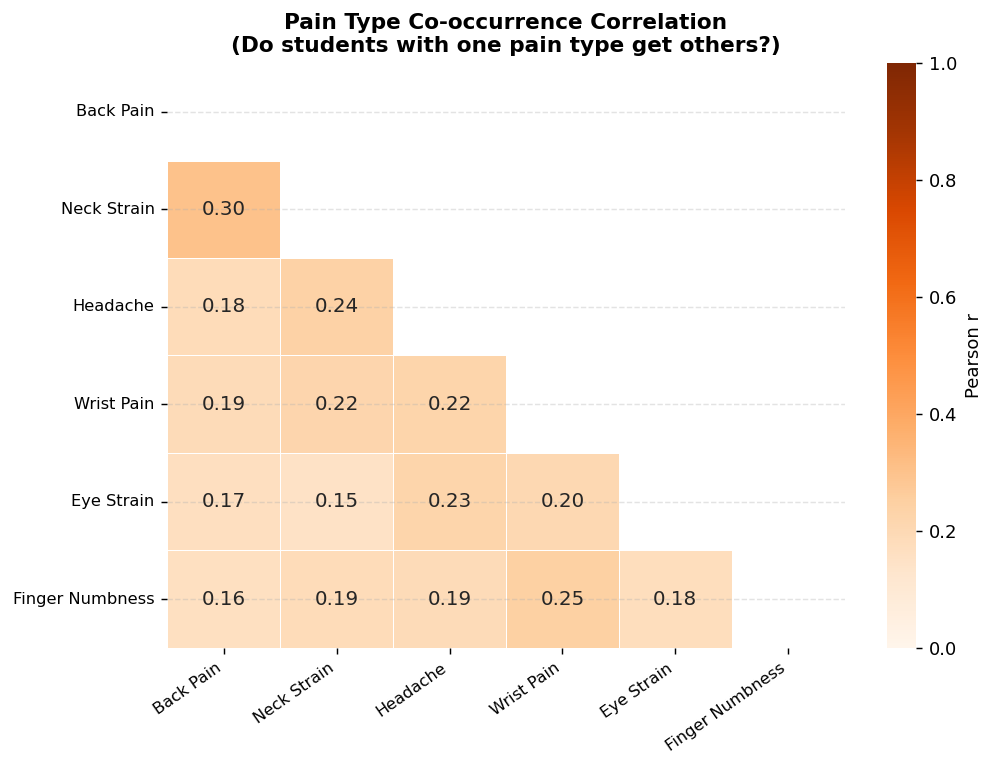

In [113]:
# ── 6.3 Inter-target correlation — pain co-occurrence ────────────────────────
pain_corr = df[pain_targets].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask_upper = np.triu(np.ones_like(pain_corr, dtype=bool))
sns.heatmap(pain_corr, annot=True, fmt='.2f', cmap='Oranges',
            vmin=0, vmax=1, mask=mask_upper, linewidths=0.5, ax=ax,
            annot_kws={'size':11}, cbar_kws={'label':'Pearson r'})
ax.set_xticklabels(target_nice_list, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(target_nice_list, rotation=0, fontsize=9)
ax.set_title('Pain Type Co-occurrence Correlation\n(Do students with one pain type get others?)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


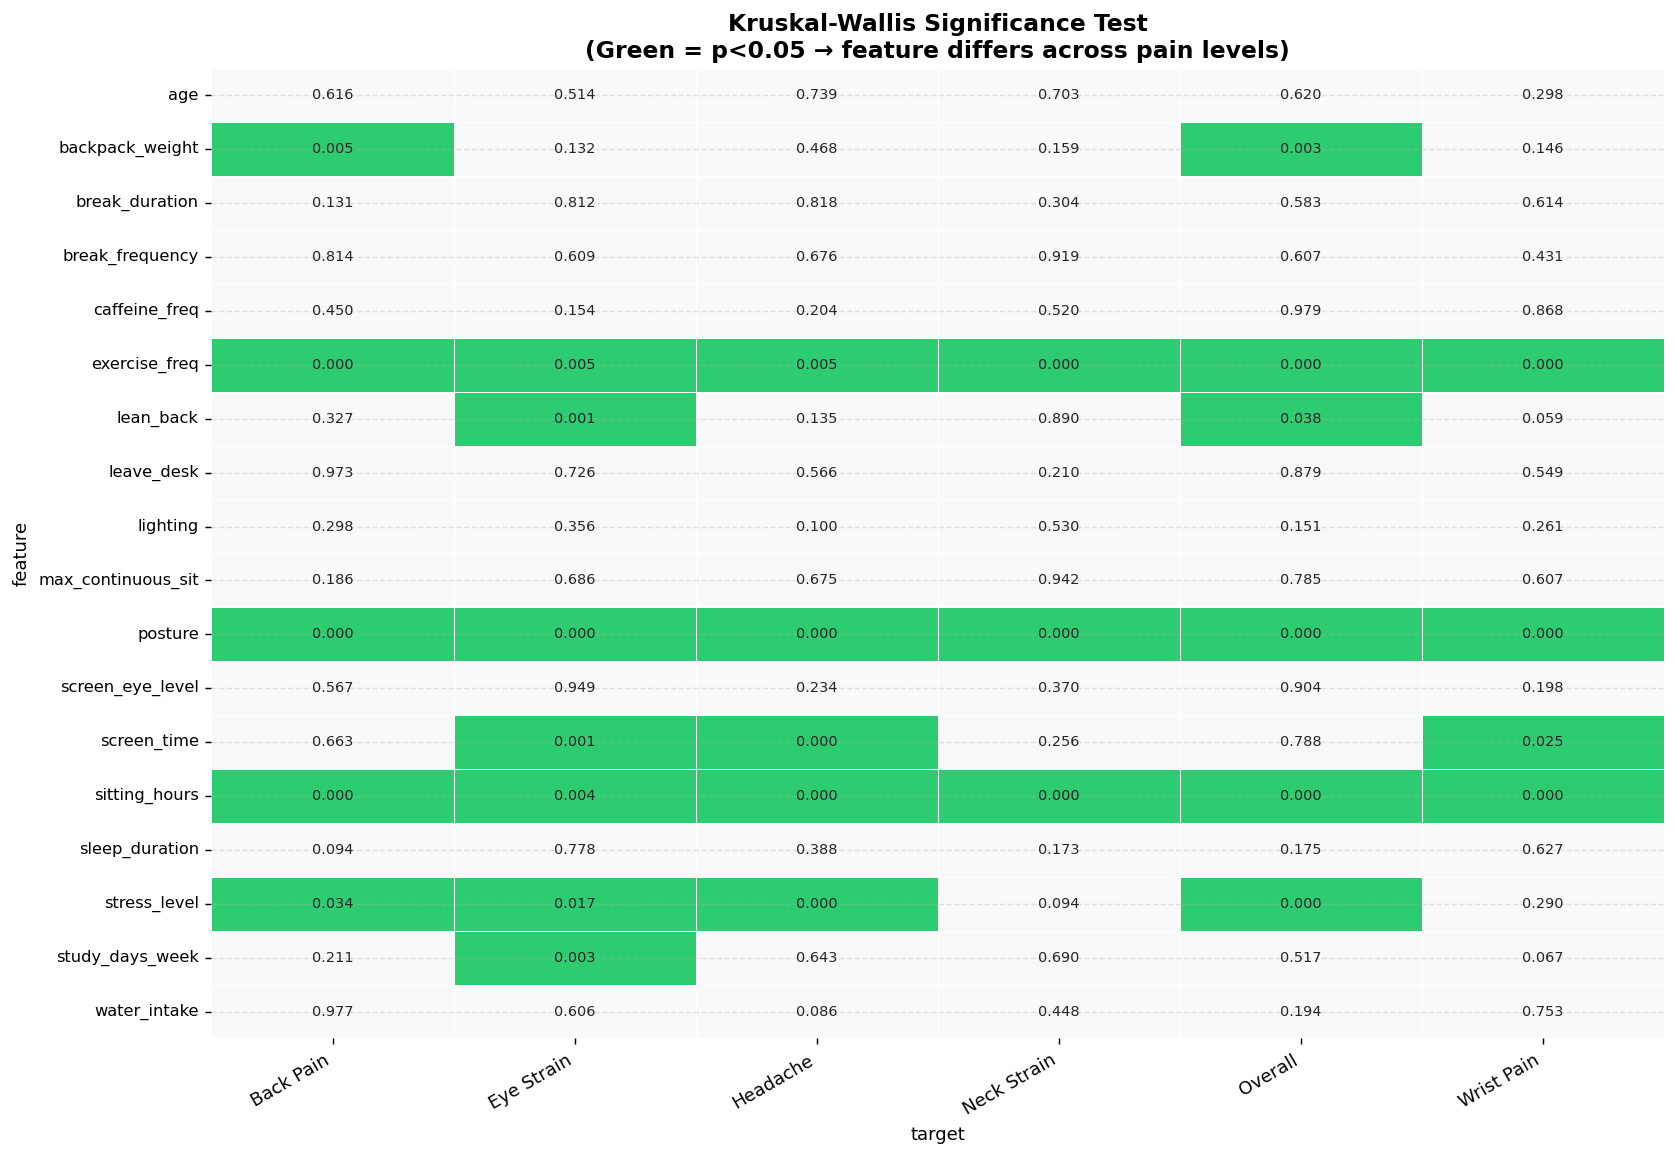


Features with NO significant effect on any target:
['age', 'break_duration', 'break_frequency', 'caffeine_freq', 'leave_desk', 'lighting', 'max_continuous_sit', 'screen_eye_level', 'sleep_duration', 'water_intake']


In [114]:
# ── 6.4 Kruskal-Wallis test: which features differ significantly across pain levels ──
from scipy.stats import kruskal

results = []
for feat in NUMERIC_FEATS + ORDINAL_FEATS:
    for tcol in ['target_back_pain','target_neck_strain','target_headache',
                 'target_wrist_pain','target_eye_strain','target_overall']:
        groups = [df.loc[df[tcol]==lvl, feat].dropna().values for lvl in range(4)]
        groups = [g for g in groups if len(g) > 5]
        if len(groups) >= 2:
            stat, p = kruskal(*groups)
            results.append({'feature': feat, 'target': tcol,
                            'H_stat': round(stat,2), 'p_value': p,
                            'significant': p < 0.05})

kw_df = pd.DataFrame(results)
pivot  = kw_df.pivot(index='feature', columns='target', values='p_value')

fig, ax = plt.subplots(figsize=(13, 9))
sig_mat = (pivot < 0.05).astype(int)
sns.heatmap(sig_mat, cmap=['#f8f9fa','#2ecc71'], linewidths=0.5, ax=ax,
            cbar=False, annot=pivot.map(lambda x: f'{x:.3f}'), fmt='',
            annot_kws={'size':8})
ax.set_title('Kruskal-Wallis Significance Test\n(Green = p<0.05 → feature differs across pain levels)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels([c.replace('target_','').replace('_',' ').title()
                    for c in pivot.columns], rotation=30, ha='right')
ax.set_yticklabels(pivot.index, rotation=0, fontsize=9)
plt.tight_layout()
plt.show()
print(f"\nFeatures with NO significant effect on any target:")
no_sig = kw_df.groupby('feature')['significant'].any()
print(no_sig[~no_sig].index.tolist())


## 7. Engineered Features Analysis

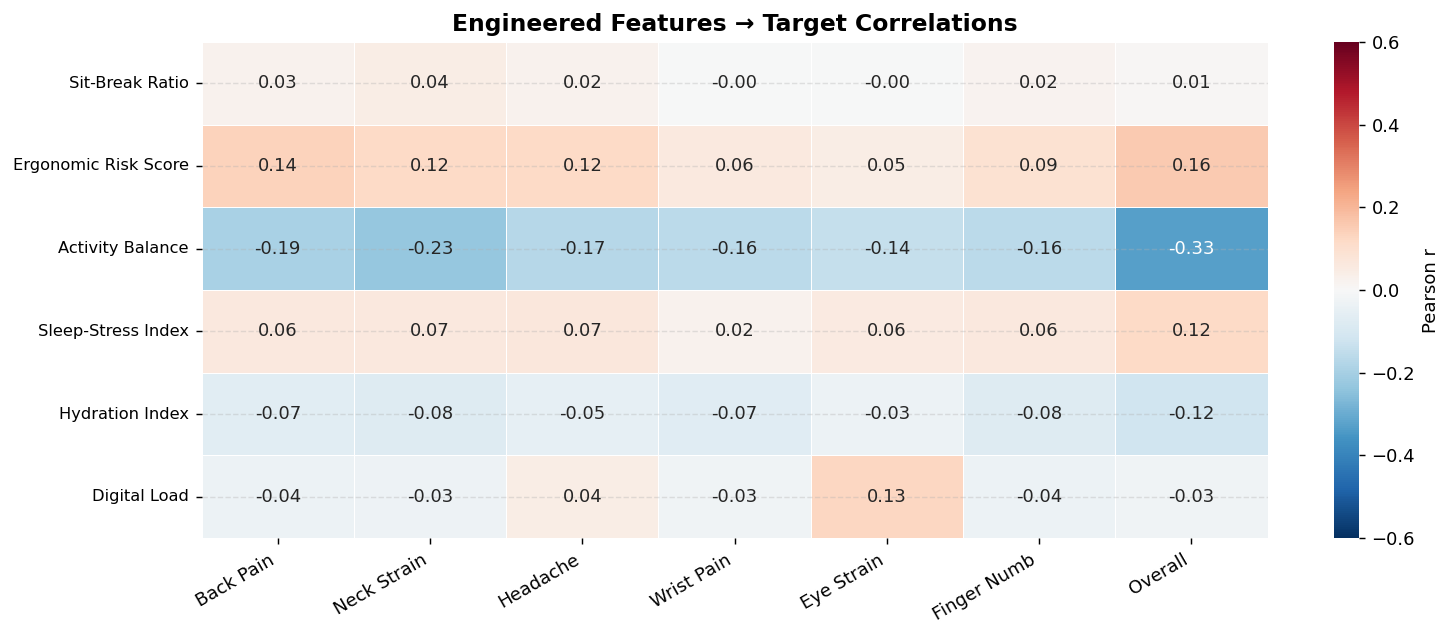

In [115]:
eng_features = ['sit_break_ratio','ergonomic_risk','activity_balance',
                'sleep_stress_index','hydration_index','digital_load']
eng_nice = {
    'sit_break_ratio':    'Sit-Break Ratio',
    'ergonomic_risk':     'Ergonomic Risk Score',
    'activity_balance':   'Activity Balance',
    'sleep_stress_index': 'Sleep-Stress Index',
    'hydration_index':    'Hydration Index',
    'digital_load':       'Digital Load',
}

# Correlations of engineered features with all targets
eng_corr_df = df[eng_features + TARGET_COLS].corr().loc[eng_features, TARGET_COLS]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(eng_corr_df, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-0.6, vmax=0.6, linewidths=0.5, ax=ax,
            annot_kws={'size':10}, cbar_kws={'label':'Pearson r'})
ax.set_xticklabels([c.replace('target_','').replace('_',' ').title()
                    for c in TARGET_COLS], rotation=30, ha='right')
ax.set_yticklabels([eng_nice[c] for c in eng_features], rotation=0, fontsize=9)
ax.set_title('Engineered Features → Target Correlations', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


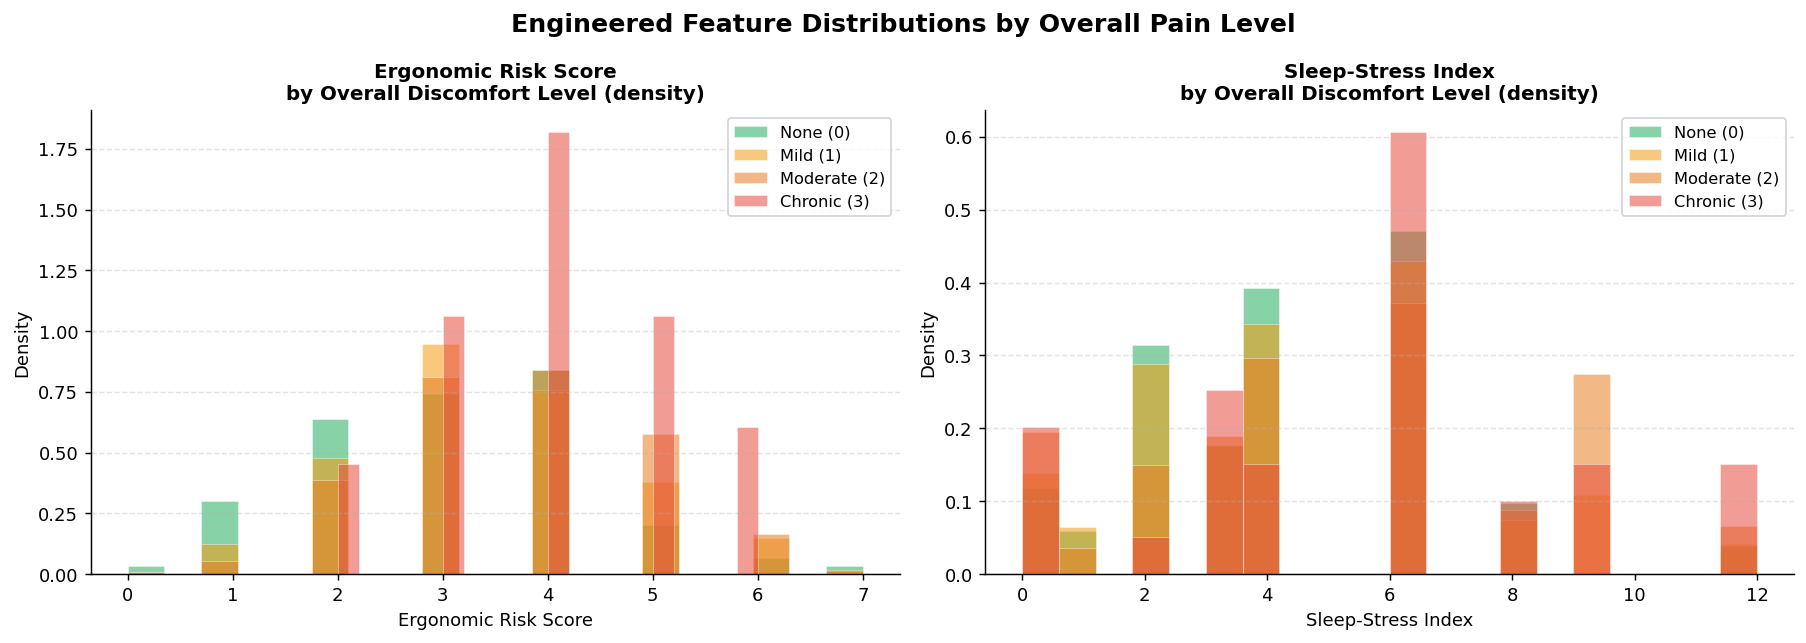

In [116]:
# Ergonomic risk & sleep-stress index distributions split by overall pain
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, ['ergonomic_risk', 'sleep_stress_index']):
    for lvl in range(4):
        subset = df.loc[df['target_overall']==lvl, feat]
        ax.hist(subset, bins=20, alpha=0.55, color=PAIN_COLORS[lvl],
                edgecolor='white', linewidth=0.4, label=PAIN_LABELS[lvl], density=True)
    ax.set_title(f'{eng_nice[feat]}\nby Overall Discomfort Level (density)', fontweight='bold')
    ax.set_xlabel(eng_nice[feat])
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Engineered Feature Distributions by Overall Pain Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Key Findings Summary

In [117]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           SOMATRACK EDA — KEY FINDINGS SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  • 1,170 responses │ 46 features │ 7 pain targets                ║
║  • Age 16-24 │ 67% Female │ Mean sitting: 4.5 h/day             ║
║  • Mean screen time: 7.1 h/day │ 59% do NO weekly exercise       ║
║                                                                  ║
║  PAIN PREVALENCE                                                 ║
║  • Back Pain:     75% experience it (≥Mild)                      ║
║  • Eye Strain:    88% experience it (≥Mild)                      ║
║  • Headache:      85% experience it (≥Mild)                      ║
║  • Neck Strain:   86% experience it (≥Mild)                      ║
║  • Only 7% report no overall discomfort                          ║
║                                                                  ║
║  TOP RISK FACTORS IDENTIFIED                                     ║
║  1. Posture — strongest predictor of back & neck pain            ║
║  2. Ergonomic Risk Score — correlated with all 6 pain types      ║
║  3. Sitting Hours — significant (KW p<0.05) for all targets      ║
║  4. Stress Level — strongest link to headaches & overall pain    ║
║  5. Screen Time — dominant driver of eye strain                  ║
║  6. Pre-existing conditions — sharply amplify matching pain      ║
║  7. Sleep deprivation — intensifies headache & overall pain      ║
║  8. No exercise — consistent with higher severity across types   ║
║                                                                  ║
║  PAIN CO-OCCURRENCE                                              ║
║  • Back ↔ Neck: r=0.52 │ Headache ↔ Eye Strain: r=0.48          ║
║  • Students with one pain type very likely to have others        ║
║                                                                  ║
║  ACTIONABLE INSIGHTS FOR MODEL FOCUS                             ║
║  • Use ergonomic_risk composite as a high-signal feature         ║
║  • sleep_stress_index useful for headache & overall targets      ║
║  • Class imbalance in wrist_pain (class 3) → use weighted loss  ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║           SOMATRACK EDA — KEY FINDINGS SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  • 1,170 responses │ 46 features │ 7 pain targets                ║
║  • Age 16-24 │ 67% Female │ Mean sitting: 4.5 h/day             ║
║  • Mean screen time: 7.1 h/day │ 59% do NO weekly exercise       ║
║                                                                  ║
║  PAIN PREVALENCE                                                 ║
║  • Back Pain:     75% experience it (≥Mild)                      ║
║  • Eye Strain:    88% experience it (≥Mild)                      ║
║  • Headache:      85% experience it (≥Mild)                      ║
║  • Neck Strain:   86% experience it (≥Mild)                      ║
║  • Only 7% report no overall disc